In [10]:
# NOTE: This file is the source for three Jupyter notebook cells.
# Copy each section into its own cell.
# =============================================================================

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports · API path · Global parameters · Fixed refractive indices ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
import os
import platform
import time
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import h5py

# ─────────────────────────────────────────────────────────────────────────────
# Lumerical installation paths
# ► Set LUMERICAL_VERSION to exactly match your installation folder name.
#   Check:  C:\Program Files\Lumerical\   and read the subfolder name.
# ─────────────────────────────────────────────────────────────────────────────
LUMERICAL_VERSION = "v202"          # ← confirmed from your traceback

if platform.system() == "Windows":
    LUMERICAL_ROOT = rf"C:\Program Files\Lumerical\{LUMERICAL_VERSION}"
    LUMERICAL_API  = rf"{LUMERICAL_ROOT}\api\python"
    LUMERICAL_BIN  = rf"{LUMERICAL_ROOT}\bin"
else:
    LUMERICAL_ROOT = f"/opt/lumerical/{LUMERICAL_VERSION}"
    LUMERICAL_API  = f"{LUMERICAL_ROOT}/api/python"
    LUMERICAL_BIN  = f"{LUMERICAL_ROOT}/bin"

# ── 1. Clear any previously cached failed import ─────────────────────────────
# If lumapi was imported and failed in this kernel session, Python stores the
# broken module in sys.modules and returns the same failure on every retry.
# Removing it forces a clean re-import.
if "lumapi" in sys.modules:
    del sys.modules["lumapi"]

# ── 2. Add the API folder to sys.path ────────────────────────────────────────
if LUMERICAL_API not in sys.path:
    sys.path.insert(0, LUMERICAL_API)

# ── 3. Register the bin directory as a DLL search path ───────────────────────
# REQUIRED on Python 3.8+ (you are on 3.11).
# os.environ["PATH"] manipulation does NOT work for CDLL() from Python 3.8
# onwards — Windows changed DLL resolution to ignore PATH by default.
# os.add_dll_directory() is the correct API.
if platform.system() == "Windows":
    if hasattr(os, "add_dll_directory"):          # Python 3.8+  ← your case
        os.add_dll_directory(str(LUMERICAL_BIN))
    else:                                          # Python < 3.8 fallback
        os.environ["PATH"] = (
            str(LUMERICAL_BIN) + ";" + os.environ.get("PATH", "")
        )

# ── 4. Verify the paths exist before importing ───────────────────────────────
assert Path(LUMERICAL_API).exists(), (
    f"Lumerical API path not found:\n  {LUMERICAL_API}\n"
    f"Check LUMERICAL_VERSION = '{LUMERICAL_VERSION}'"
)
assert Path(LUMERICAL_BIN).exists(), (
    f"Lumerical bin path not found:\n  {LUMERICAL_BIN}"
)

import lumapi  # noqa — must come after all path setup above
print(f"lumapi imported successfully from:\n  {lumapi.__file__}")

# ─────────────────────────────────────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s │ %(levelname)s │ %(message)s",
    datefmt = "%H:%M:%S",
)
log = logging.getLogger("SiN_FDE")

# ─────────────────────────────────────────────────────────────────────────────
# I/O  ─ directory and HDF5 output path
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME = "LUM_SiN_STRp_400nm_wdth_sweep_V1"
PROJECT_DIR  = Path.cwd()
DATA_DIR     = PROJECT_DIR / "data_STRp_SiN_mode_analysis_LUM"
DATA_DIR.mkdir(parents=True, exist_ok=True)
HDF5_PATH    = DATA_DIR / f"{VERSION_NAME}.h5"

# ─────────────────────────────────────────────────────────────────────────────
# Waveguide geometry  (µm throughout unless stated)
#
#  Cross-section  (Y-Z plane, X = propagation direction):
#
#     ┌────────────────────────────────────────────┐
#     │        Aqueous  n = 1.33  (upper clad)     │  z >  +core_t/2
#     │     ┌────────────────────┐                 │
#     │     │       SiN          │  core_t = 0.4   │  z ∈ [-0.2, +0.2] µm
#     │     └────────────────────┘                 │
#     │        SiO₂  n = 1.4469  (lower clad)      │  z < -0.2 µm
#     └────────────────────────────────────────────┘
#              ←—— width sweep ——→
# ─────────────────────────────────────────────────────────────────────────────
CORE_THICKNESS_UM  = 0.400    # SiN core height  [µm]
N_MODES_REQUEST    = 6        # max modes to request from the FDE eigenvalue solver

# Simulation domain margins
SIM_Y_MARGIN_UM    = 2.5      # lateral cladding margin each side beyond core half-width [µm]
SIM_Z_BELOW_UM     = 2.0      # SiO₂ substrate depth below core bottom [µm]
SIM_Z_ABOVE_UM     = 2.0      # aqueous depth above core top           [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Fixed refractive indices  (evaluated at 1550 nm via Sellmeier,
# held constant across the entire wavelength and width sweep)
#
#   n_SiN  = sqrt(1 + 2.9144·λ²/(λ²-0.1366²) + 0.004873/(λ²-1.6606²))
#          → 1.980780 at 1550 nm
#
#   n_SiO2 = sqrt(1 + 1.1056·λ²/(λ²-0.078²) + 2.360·λ²/(λ²-16.681²)) + 0.002
#          → 1.446940 at 1550 nm
#
#   n_aq   = 1.33   (aqueous medium, constant by definition)
# ─────────────────────────────────────────────────────────────────────────────
N_SIN_FIXED   = 1.99   # SiN  @ 1550 nm  — used for FDE index and mesh sizing
N_SIO2_FIXED  = 1.4469   # SiO₂ @ 1550 nm  — used for FDE index and guided-mode cutoff
N_UPPER_CLADDING = 1.33  # aqueous medium   — used for FDE index (constant)

# ─────────────────────────────────────────────────────────────────────────────
# Width sweep   600 nm → 1500 nm,  100 uniformly-spaced points
# ─────────────────────────────────────────────────────────────────────────────
SWEEP_WIDTHS_UM = np.linspace(0.600, 1.500, 100)    # [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Wavelength sweep  :  λ₀ = 1550 nm  +  12 jumps of (10/13) nm  →  13 points
#
#   λₙ = 1550 + n × (10/13)  nm      n = 0, 1, … 12
#   λ₁₂ = 1550 + 120/13 ≈ 1559.2308 nm
# ─────────────────────────────────────────────────────────────────────────────
LAMBDA_START_NM  = 1550.0
DELTA_LAMBDA_NM  = 10.0 / 13.0          # ≈ 0.769231 nm  (exact rational step)
N_WAVELENGTHS    = 13                    # 0 … 12 inclusive
SWEEP_WL_NM  = LAMBDA_START_NM + np.arange(N_WAVELENGTHS) * DELTA_LAMBDA_NM
SWEEP_WL_UM  = SWEEP_WL_NM * 1e-3       # [µm]
SWEEP_WL_M   = SWEEP_WL_UM * 1e-6       # [m]  — Lumerical SI units

# ─────────────────────────────────────────────────────────────────────────────
# Derived domain dimensions
# ─────────────────────────────────────────────────────────────────────────────
# y: accommodate the widest core (1.5 µm) + 2 × lateral margin
SIM_Y_SPAN_UM  = SWEEP_WIDTHS_UM.max() + 2.0 * SIM_Y_MARGIN_UM      # 6.5 µm

# z: SiO₂ below  +  core  +  aqueous above
SIM_Z_SPAN_UM  = SIM_Z_BELOW_UM + CORE_THICKNESS_UM + SIM_Z_ABOVE_UM # 4.4 µm

# ─────────────────────────────────────────────────────────────────────────────
# Mesh sizing:  target ≈ λ_max / (N_SIN_FIXED × 10)
#   i.e. 10 mesh cells per wavelength inside the core material.
#   N_SIN_FIXED is used directly here — no separate approximation variable.
#
# Raise MESH_CELLS_PER_WVL to 15–20 for publication-grade neff accuracy.
# ─────────────────────────────────────────────────────────────────────────────
MESH_CELLS_PER_WVL = 10
_mesh_step_um      = SWEEP_WL_UM.max() / (N_SIN_FIXED * MESH_CELLS_PER_WVL)
MESH_CELLS_Y       = int(np.ceil(SIM_Y_SPAN_UM / _mesh_step_um))   # ≈ 83
MESH_CELLS_Z       = int(np.ceil(SIM_Z_SPAN_UM / _mesh_step_um))   # ≈ 56

# ─────────────────────────────────────────────────────────────────────────────
# Summary printout
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 62)
print("  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)")
print("=" * 62)
print(f"  Version      : {VERSION_NAME}")
print(f"  Widths       : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)")
print(f"  Wavelengths  : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts,  Δλ = 10/13 ≈ {DELTA_LAMBDA_NM:.5f} nm)")
print(f"  Core h       : {CORE_THICKNESS_UM*1e3:.0f} nm")
print(f"  n_SiN        : {N_SIN_FIXED}  (fixed @ 1550 nm)")
print(f"  n_SiO₂       : {N_SIO2_FIXED}  (fixed @ 1550 nm)  ← guided-mode cutoff")
print(f"  n_aqueous    : {N_UPPER_CLADDING}  (constant)")
print(f"  Domain       : y = {SIM_Y_SPAN_UM:.2f} µm,  z = {SIM_Z_SPAN_UM:.2f} µm")
print(f"  Mesh step    : ≈ {_mesh_step_um*1e3:.1f} nm  "
      f"({MESH_CELLS_Y} × {MESH_CELLS_Z} cells,  "
      f"≈ λ_max / (n_SiN × {MESH_CELLS_PER_WVL}))")
print(f"  Total FDE    : {len(SWEEP_WIDTHS_UM)} × {N_WAVELENGTHS} = "
      f"{len(SWEEP_WIDTHS_UM)*N_WAVELENGTHS} runs")
print(f"  HDF5 output  : {HDF5_PATH}")
print("=" * 62)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — FDE helpers  +  main sweep function                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# Helper 1 :  _init_fde_geometry
#   Clears the session, creates the FDE solver region and the three material
#   rectangles.  Called ONCE at the start; geometry is then updated in-loop
#   via setnamed() to avoid rebuilding from scratch on every width step.
#
#   Material indices are set from the fixed constants N_SIN_FIXED,
#   N_SIO2_FIXED, N_UPPER_CLADDING — no Sellmeier evaluation.
#
#   Structure override order (same default mesh-order → last added wins):
#     1st added  →  Aqueous_bg          (background, lowest priority)
#     2nd added  →  SiO2_lower_clad     (overrides Aqueous below the core)
#     3rd added  →  SiN_core            (overrides everything, highest priority)
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
):
    """
    Creates FDE solver region + three material rectangles in a clean session.
    Indices are taken directly from the module-level constants
    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : Aqueous background (full domain, lowest priority) ────
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_UPPER_CLADDING)             # 1.33, constant

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    # Spans full y, from domain bottom up to the core bottom (z = -core_t/2)
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)                 # 1.4469, fixed

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    # y span is updated in the inner width loop; all other dims are fixed.
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)                  # 1.9808, fixed


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2 :  _extract_mode_results
#   After findmodes() reads neff (complex), TE polarization fraction, and
#   counts guided modes.
#
#   Guided criterion:  Re(neff) > N_SIO2_FIXED
#   This is the physically correct cutoff for an asymmetric waveguide whose
#   highest-index cladding is SiO₂.  Radiation modes discretised by the
#   finite simulation domain have neff < N_SIO2_FIXED and are filtered out.
#
#   Returns arrays of shape (n_modes_request,) — NaN where a mode was not found.
# ─────────────────────────────────────────────────────────────────────────────
def _extract_mode_results(mode, n_modes_request: int):
    """
    Extract neff (complex), TE fraction, and guided-mode count from the FDE
    result after findmodes().

    Uses N_SIO2_FIXED (module-level constant) as the guided-mode cutoff.

    Returns
    -------
    neff_real : np.ndarray  (n_modes_request,)   Re(neff), NaN if not found
    neff_imag : np.ndarray  (n_modes_request,)   Im(neff)
    te_frac   : np.ndarray  (n_modes_request,)   TE polarization fraction
    n_guided  : int                               count of guided modes
    """
    neff_real = np.full(n_modes_request, np.nan, dtype=np.float64)
    neff_imag = np.full(n_modes_request, np.nan, dtype=np.float64)
    te_frac   = np.full(n_modes_request, np.nan, dtype=np.float64)
    n_guided  = 0

    for m_i in range(1, n_modes_request + 1):
        mode_grp = f"FDE::data::mode{m_i}"
        try:
            raw_neff = mode.getdata(mode_grp, "neff")
            raw_te   = mode.getdata(mode_grp, "TE polarization fraction")
        except Exception:
            break   # no more modes available — stop

        # Normalise to Python scalar regardless of array shape returned
        neff_c = complex(np.asarray(raw_neff).flat[0])
        te_v   = float(np.asarray(raw_te).flat[0])

        neff_real[m_i - 1] = neff_c.real
        neff_imag[m_i - 1] = neff_c.imag
        te_frac  [m_i - 1] = te_v

        # Guided-mode test: Re(neff) must exceed the highest cladding index
        if neff_c.real > N_SIO2_FIXED:
            n_guided += 1

    return neff_real, neff_imag, te_frac, n_guided


# ─────────────────────────────────────────────────────────────────────────────
# Helper 3 :  _init_hdf5
#   Creates a fresh HDF5 file with pre-allocated datasets and full metadata.
#   Uses chunked storage so incremental slice-writes are efficient.
# ─────────────────────────────────────────────────────────────────────────────
def _init_hdf5(
    path            : Path,
    n_w             : int,
    n_wl            : int,
    n_modes         : int,
    sweep_widths_um : np.ndarray,
    sweep_wl_um     : np.ndarray,
    metadata        : dict,
):
    with h5py.File(path, "w") as f:
        # — metadata group ————————————————————————————————————————————————————
        md = f.create_group("metadata")
        md.create_dataset("sweep_widths_um",      data=sweep_widths_um)
        md.create_dataset("sweep_wavelengths_nm", data=sweep_wl_um * 1e3)
        md.create_dataset("sweep_wavelengths_um", data=sweep_wl_um)
        for k, v in metadata.items():
            md.attrs[k] = v
        md.attrs["timestamp_start"] = datetime.now().isoformat()

        # — result datasets  (NaN-initialised, chunked per width row) ─────────
        chunk_shape = (1, n_wl, n_modes)
        nan3d = np.full((n_w, n_wl, n_modes), np.nan, dtype=np.float64)
        rg = f.create_group("results")
        rg.create_dataset("neff_real", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("neff_imag", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("te_frac",   data=nan3d, chunks=chunk_shape)
        rg.create_dataset("n_guided",
                          data=np.zeros((n_w, n_wl), dtype=np.int32),
                          chunks=(1, n_wl))

        # — progress flag ─────────────────────────────────────────────────────
        f.create_group("flags").create_dataset(
            "computed",
            data=np.zeros((n_w, n_wl), dtype=bool),
            chunks=(1, n_wl),
        )


# ─────────────────────────────────────────────────────────────────────────────
# Main function :  run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,           # set True for headless / HPC runs
):
    """
    2-D FDE width sweep for a straight SiN waveguide on SiO₂ with aqueous top
    cladding, using Lumerical MODE Solutions via the Python lumapi.

    Material indices are fixed constants (N_SIN_FIXED, N_SIO2_FIXED,
    N_UPPER_CLADDING) — no Sellmeier evaluation at any point.

    Sweep axes
    ----------
    - Inner  :  SiN core y-span  (600 nm → 1500 nm,  100 pts)
    - Outer  :  wavelength        (1550.0 nm → 1559.23 nm,  13 pts)

    At each (width, λ) point the function
      1. Updates the FDE solver wavelength and the core y-span.
      2. Runs mesh  →  findmodes()  →  extracts neff + TE fraction.
      3. Counts guided modes  (Re(neff) > N_SIO2_FIXED).
      4. Writes results to HDF5 immediately and flushes — safe to interrupt.

    Re-running skips already-computed points automatically (cache check via
    flags/computed dataset in HDF5).

    Returns
    -------
    dict with keys:
        neff_real       np.ndarray  [n_widths, n_wl, n_modes_request]
        neff_imag       np.ndarray  [n_widths, n_wl, n_modes_request]
        te_frac         np.ndarray  [n_widths, n_wl, n_modes_request]
        n_guided        np.ndarray  [n_widths, n_wl]
        computed        np.ndarray  [n_widths, n_wl]  bool
        sweep_widths_um np.ndarray  [n_widths]  µm
        sweep_wl_nm     np.ndarray  [n_wl]      nm
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute all fixed geometry quantities ─────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um

    # Core sits at z = 0  →  SiO₂ slab spans  z ∈ [-(half_t + sim_z_below), -half_t]
    sio2_z_span = sim_z_below_um
    sio2_z_ctr  = -(half_t + sim_z_below_um / 2.0)

    # Simulation region centre (= 0 when below == above, i.e. symmetric domain)
    sim_z_ctr   = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : N_UPPER_CLADDING,
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        # Wavelength for the initial FDE setup: first point of the sweep.
        # Derived from the function parameter sweep_wl_um — not from any global.
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),   # µm → m
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        # ── Keep HDF5 open for the entire sweep  (flush after each point) ─────
        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                # Fast-skip: all widths at this λ already cached
                if computed[:, wl_idx].all():
                    continue

                # Wavelength in SI metres — derived from function parameter
                wl_m = float(wl_um * 1e-6)

                # Only the FDE solver wavelength changes per outer iteration.
                # Material indices are fixed — no setnamed index update here.
                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  n_SiO₂ = {N_SIO2_FIXED}  "
                    f"n_aq = {N_UPPER_CLADDING}  (all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    # ── Cache check ───────────────────────────────────────
                    if computed[w_idx, wl_idx]:
                        continue

                    # ── Update core width (only geometry change per step) ──
                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    # ── Run FDE mesh  →  find modes ───────────────────────
                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        # Mark as done with NaN result to skip on re-run
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    # ── Extract and classify modes ─────────────────────────
                    # n_found is passed only for awareness; _extract_mode_results
                    # iterates up to n_modes_request and breaks on missing modes.
                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    # ── Store in memory ───────────────────────────────────
                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    # ── Write to HDF5  (incremental, fault-safe) ──────────
                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    # ── Progress report every 10 completed runs ───────────
                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            # ── Close-out metadata ────────────────────────────────────────
            hf["metadata"].attrs["timestamp_end"]   = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"]  = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Execute sweep + quick sanity output                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

results = run_width_sweep_fde()

# ── Unpack for downstream cells ───────────────────────────────────────────────
neff_real       = results["neff_real"]          # [n_widths, n_wl, n_modes]
neff_imag       = results["neff_imag"]
te_frac         = results["te_frac"]
n_guided        = results["n_guided"]           # [n_widths, n_wl]
computed        = results["computed"]
sweep_widths_um = results["sweep_widths_um"]    # [100]  µm
sweep_wl_nm     = results["sweep_wl_nm"]        # [13]   nm

print("\n" + "=" * 58)
print("  Sweep complete — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided.shape}")
print(f"  Points computed  : {computed.sum()} / {computed.size}")
print(f"  HDF5 saved to    : {HDF5_PATH}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided[i, 0]
    ne0    = neff_real[i, 0, 0]
    te0    = te_frac [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

23:04:46 │ INFO │ Cache found → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5


lumapi imported successfully from:
  C:\Program Files\Lumerical\v202\api\python\lumapi.py
  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)
  Version      : LUM_SiN_STRp_400nm_wdth_sweep_V1
  Widths       : 600 → 1500 nm  (100 pts)
  Wavelengths  : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 ≈ 0.76923 nm)
  Core h       : 400 nm
  n_SiN        : 1.99  (fixed @ 1550 nm)
  n_SiO₂       : 1.4469  (fixed @ 1550 nm)  ← guided-mode cutoff
  n_aqueous    : 1.33  (constant)
  Domain       : y = 6.50 µm,  z = 4.40 µm
  Mesh step    : ≈ 78.4 nm  (83 × 57 cells,  ≈ λ_max / (n_SiN × 10))
  Total FDE    : 100 × 13 = 1300 runs
  HDF5 output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5


23:04:46 │ INFO │ Cached: 1300/1300  |  Remaining: 0
23:04:46 │ INFO │ All points already computed — returning cached results.



  Sweep complete — result summary
  neff_real shape  : (100, 13, 6)  (widths × λ × modes)
  n_guided  shape  : (100, 13)
  Points computed  : 1300 / 1300
  HDF5 saved to    : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5

  Guided-mode count at λ = 1550.0000 nm  (first 15 widths):
  Width [nm]    n_guided    neff_mode0   TE_frac_0
  ----------------------------------------------
       600.0           2       1.49352       0.988
       609.1           2       1.49631       0.988
       618.2           2       1.49915       0.989
       627.3           2       1.50825       0.988
       636.4           2       1.51104       0.988
       645.5           2       1.51383       0.988
       654.5           2       1.51577       0.988
       663.6           2       1.51882       0.988
       672.7           2       1.52204       0.988
       681.8           2       1.52544       0.988
       690.9         

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — SiO₂ cladding sweep : new constants + extended functions         ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–3 ALREADY EXECUTED.                                       ║
# ║  All imports, sweep arrays, mesh constants, helper functions and the        ║
# ║  first-sweep result dict are live in the kernel namespace.                  ║
# ║                                                                             ║
# ║  Only two things change vs the aqueous sweep:                               ║
# ║    1. The background/upper-cladding index  (1.33 → N_SIO2_FIXED = 1.4469)  ║
# ║    2. The output HDF5 file                                                  ║
# ║                                                                             ║
# ║  Strategy: extend _init_fde_geometry and run_width_sweep_fde with one new  ║
# ║  optional parameter each (default = original value → zero behaviour        ║
# ║  change for the aqueous sweep if it is ever re-run).                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# New constants only — nothing from Cell 1 is repeated
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME_SIO2     = "LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1"
HDF5_PATH_SIO2        = DATA_DIR / f"{VERSION_NAME_SIO2}.h5"
N_UPPER_CLADDING_SIO2 = N_SIO2_FIXED      # 1.4469 — Silica replaces aqueous

print(f"SiO₂-cladding sweep")
print(f"  version  : {VERSION_NAME_SIO2}")
print(f"  output   : {HDF5_PATH_SIO2}")
print(f"  n_upper  : {N_UPPER_CLADDING_SIO2}  (Silica, symmetric stack)")
print(f"  n_lower  : {N_SIO2_FIXED}  (SiO₂ substrate — unchanged)")
print(f"  n_core   : {N_SIN_FIXED}   (SiN core — unchanged)")
print(f"  cutoff   : Re(neff) > {N_SIO2_FIXED}  (same threshold, now symmetric)")
print()

# ─────────────────────────────────────────────────────────────────────────────
# Extended _init_fde_geometry
# ─────────────────────────────────────────────────────────────────────────────
# ONE change vs Cell-2 version:
#   parameter  n_background (default = N_UPPER_CLADDING)  replaces the
#   hardcoded  N_UPPER_CLADDING  on the Aqueous_bg rectangle.
# All other geometry, mesh and solver settings are identical.
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
    n_background      = N_UPPER_CLADDING,  # ← NEW: upper/lateral cladding index
                                           #   default keeps aqueous behaviour
):
    """
    Creates FDE solver region + three material rectangles in a clean session.

    n_background sets the index of the Aqueous_bg rectangle (upper and lateral
    cladding).  Defaults to N_UPPER_CLADDING (1.33, aqueous) so the original
    call in run_width_sweep_fde remains valid without any argument change.
    Pass N_SIO2_FIXED (1.4469) for the symmetric SiO₂-cladding sweep.

    N_SIN_FIXED and N_SIO2_FIXED (core and lower cladding) are always taken
    from module-level constants — they never change between sweeps.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : background (full domain, lowest priority) ─────────────
    # Name kept as "Aqueous_bg" for consistency; index is n_background.
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    n_background)                  # ← ONLY line changed

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


# ─────────────────────────────────────────────────────────────────────────────
# Extended run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
# THREE changes vs Cell-2 version (all keyed on the new n_upper_cladding param):
#   1. parameter  n_upper_cladding  (default = N_UPPER_CLADDING)  added to sig
#   2. metadata dict key  "n_upper_cladding"  uses the parameter, not the const
#   3. _init_fde_geometry call passes  n_background = n_upper_cladding
#   4. log.info message shows n_upper_cladding instead of the hardcoded const
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,
    n_upper_cladding   = N_UPPER_CLADDING,  # ← NEW: default = aqueous (1.33)
):
    """
    2-D FDE width sweep for a straight SiN waveguide.

    n_upper_cladding controls the lateral and upper background index:
      - N_UPPER_CLADDING (1.33)  →  aqueous cladding  [original behaviour]
      - N_SIO2_FIXED     (1.4469) →  symmetric SiO₂ stack

    All other parameters, data structures, caching and HDF5 logic are
    identical to the original Cell-2 version.
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute fixed geometry quantities ─────────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um
    sio2_z_span    = sim_z_below_um
    sio2_z_ctr     = -(half_t + sim_z_below_um / 2.0)
    sim_z_ctr      = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : n_upper_cladding,   # ← CHANGE 1: param, not const
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
            n_background    = n_upper_cladding,          # ← CHANGE 2: forwarded
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                if computed[:, wl_idx].all():
                    continue

                wl_m = float(wl_um * 1e-6)

                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  "
                    f"n_lower = {N_SIO2_FIXED}  "
                    f"n_upper = {n_upper_cladding}  "    # ← CHANGE 3: param
                    f"(all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    if computed[w_idx, wl_idx]:
                        continue

                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            hf["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"] = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


print("Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.")
print("Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Execute SiO₂ cladding sweep                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Only three arguments differ from the aqueous sweep defaults:
#   n_upper_cladding → N_UPPER_CLADDING_SIO2  (the material change)
#   hdf5_path        → HDF5_PATH_SIO2          (separate output file)
#   version_name     → VERSION_NAME_SIO2        (separate metadata label)
# All sweep arrays, mesh, geometry and solver settings are inherited.

print("=" * 62)
print("  SiN Straight Waveguide — SiO₂ symmetric cladding sweep")
print("=" * 62)
print(f"  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)")
print(f"  n_upper = n_lower = {N_UPPER_CLADDING_SIO2}  (Silica)")
print(f"  Widths  : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)  — inherited")
print(f"  λ range : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts)  — inherited")
print(f"  Output  : {HDF5_PATH_SIO2}")
print("=" * 62)

results_sio2 = run_width_sweep_fde(
    n_upper_cladding = N_UPPER_CLADDING_SIO2,
    hdf5_path        = HDF5_PATH_SIO2,
    version_name     = VERSION_NAME_SIO2,
)

# ── Unpack into clearly namespaced variables for downstream cells ─────────────
neff_real_sio2       = results_sio2["neff_real"]       # [n_widths, n_wl, n_modes]
neff_imag_sio2       = results_sio2["neff_imag"]
te_frac_sio2         = results_sio2["te_frac"]
n_guided_sio2        = results_sio2["n_guided"]        # [n_widths, n_wl]
computed_sio2        = results_sio2["computed"]
# sweep_widths_um and sweep_wl_nm are identical to the aqueous sweep —
# no new variable needed; downstream cells reference the originals.

print("\n" + "=" * 58)
print("  SiO₂ cladding sweep — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real_sio2.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided_sio2.shape}")
print(f"  Points computed  : {computed_sio2.sum()} / {computed_sio2.size}")
print(f"  HDF5 saved to    : {HDF5_PATH_SIO2}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided_sio2[i, 0]
    ne0    = neff_real_sio2[i, 0, 0]
    te0    = te_frac_sio2  [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

23:04:46 │ INFO │ Cache found → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
23:04:46 │ INFO │ Cached: 1300/1300  |  Remaining: 0
23:04:46 │ INFO │ All points already computed — returning cached results.


SiO₂-cladding sweep
  version  : LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1
  output   : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
  n_upper  : 1.4469  (Silica, symmetric stack)
  n_lower  : 1.4469  (SiO₂ substrate — unchanged)
  n_core   : 1.99   (SiN core — unchanged)
  cutoff   : Re(neff) > 1.4469  (same threshold, now symmetric)

Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.
Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).
  SiN Straight Waveguide — SiO₂ symmetric cladding sweep
  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)
  n_upper = n_lower = 1.4469  (Silica)
  Widths  : 600 → 1500 nm  (100 pts)  — inherited
  λ range : 1550.0000 → 1559.2308 nm  (13 pts)  — inherited
  Output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5

  Post-processing summary — polarization-resolved mode analysis
  Width : 600 → 1500 nm  (100 pts)
  λ     : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 nm)

  Aqueous  (n_upper = 1.33)
    TE  max modes = 2  │  MM cutoff ≈ 1309 nm
    TM  max modes = 1  │  single-mode across full sweep

  Silica   (n_upper = 1.4469)
    TE  max modes = 2  │  MM cutoff ≈ 1100 nm
    TM  max modes = 2  │  MM cutoff ≈ 1236 nm

──────────────────────────────────────────────────────────────
  Plotting: Aqueous cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.pdf


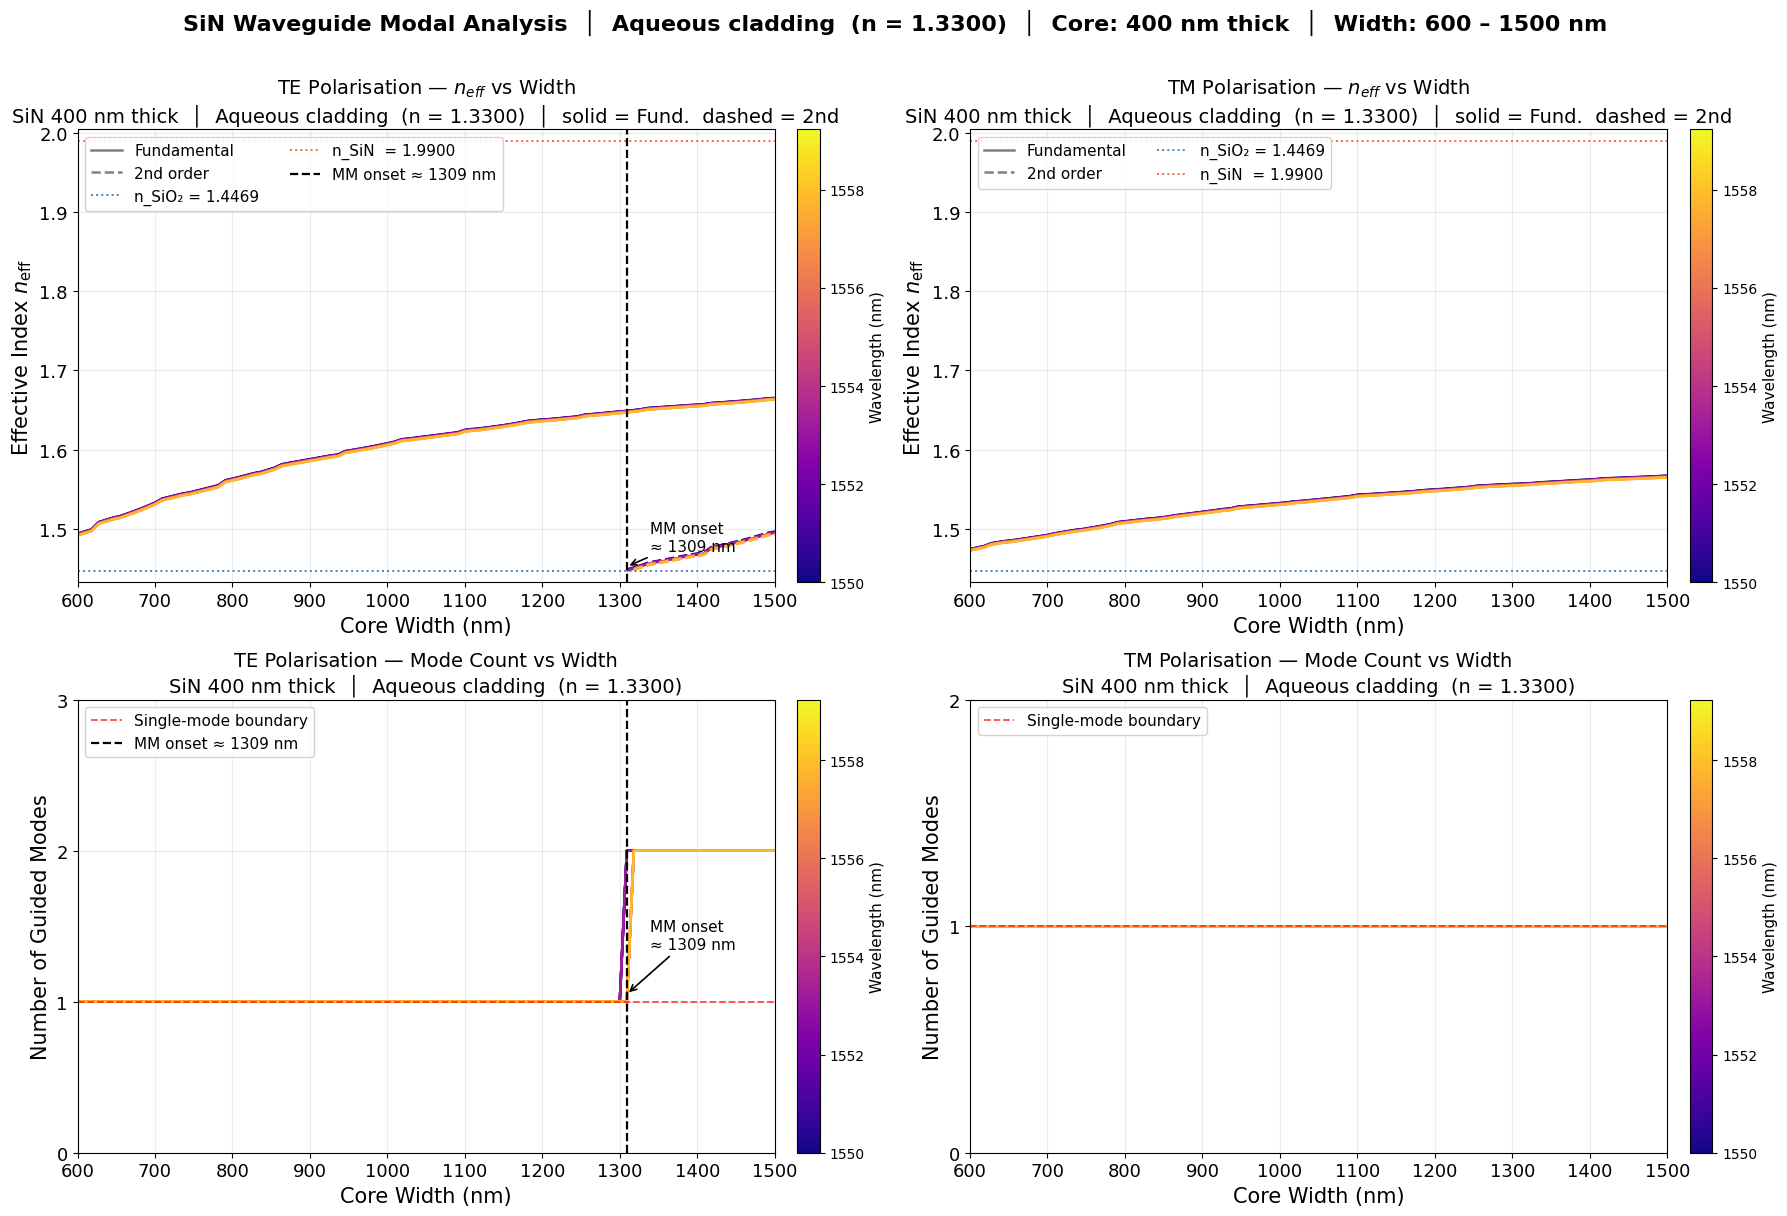


──────────────────────────────────────────────────────────────
  Plotting: Silica cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.pdf


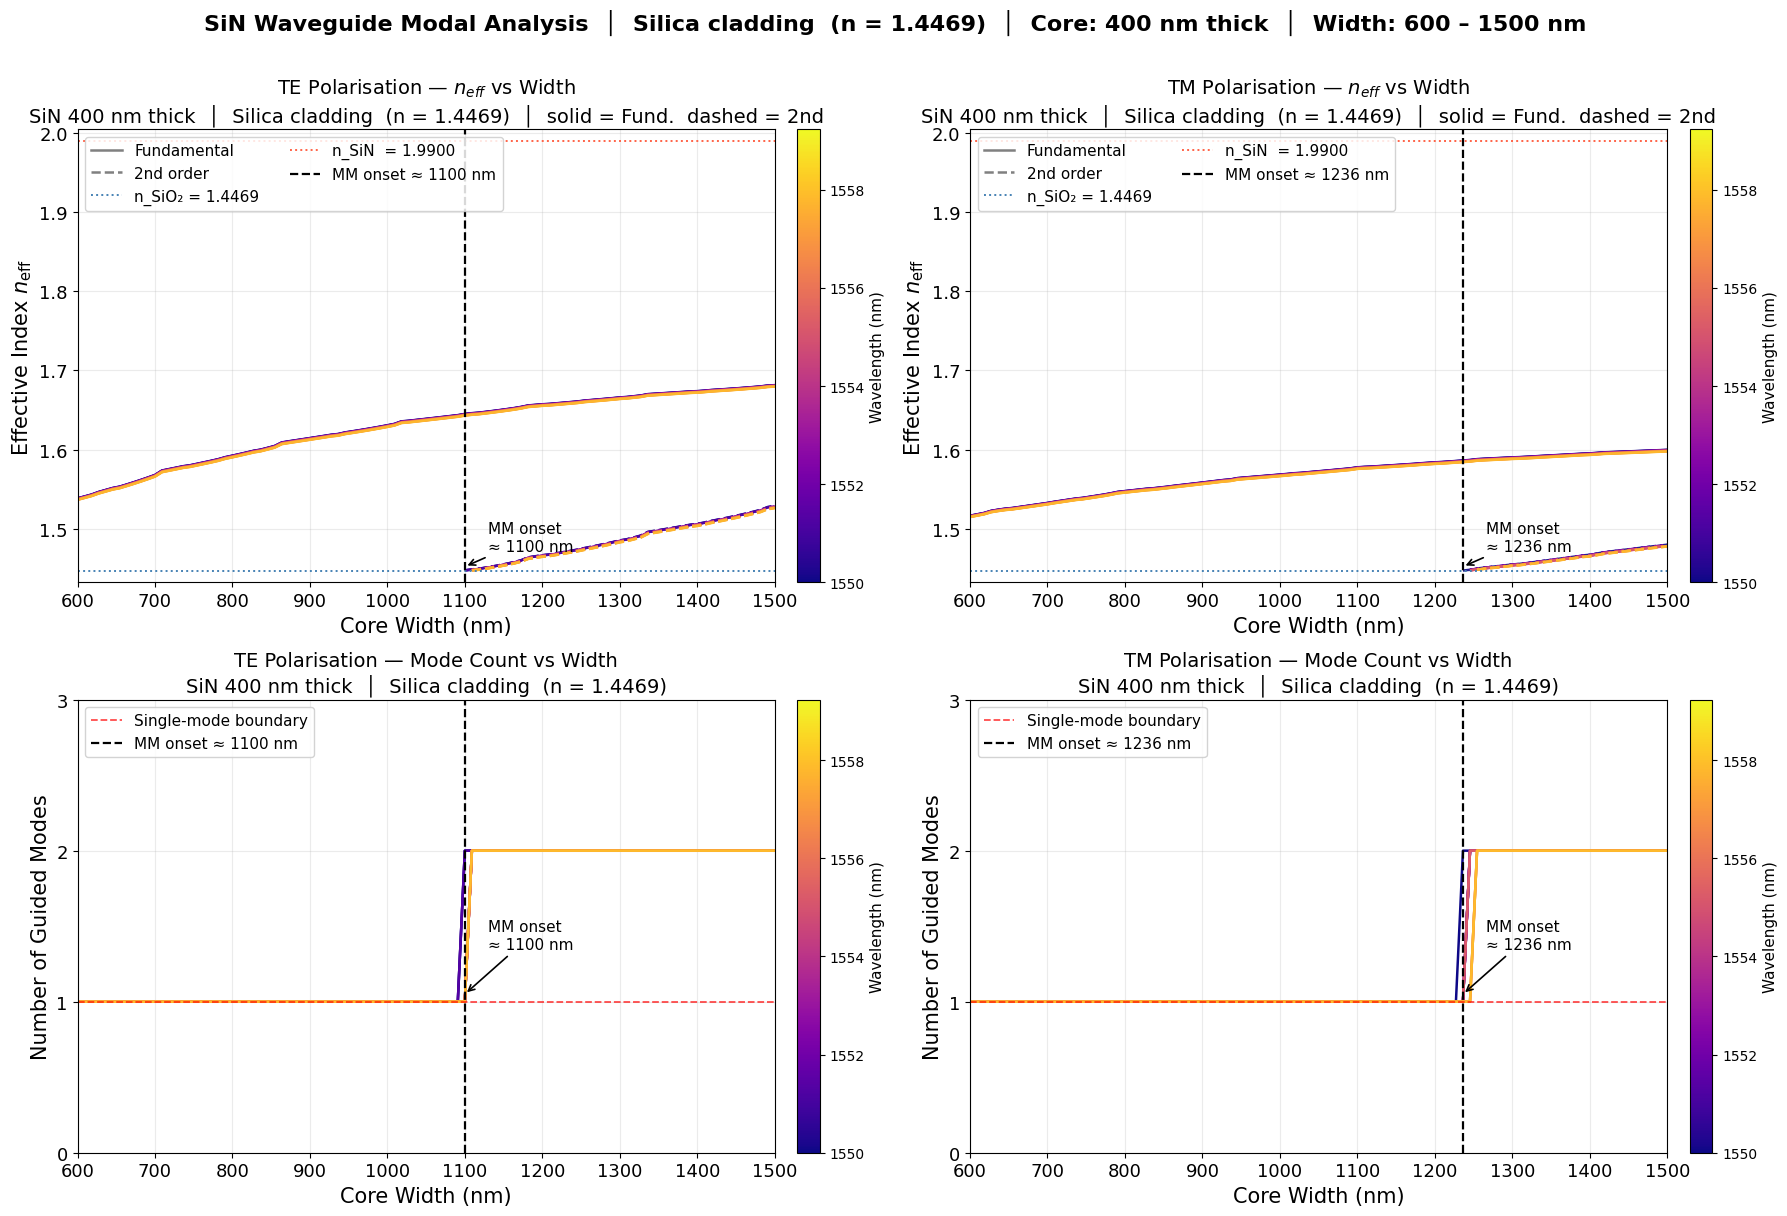

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Post-processing: TE/TM extraction for both cladding sweeps      ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–5 ALREADY EXECUTED.                                       ║
# ║  Reuses without redefining:                                                 ║
# ║    SWEEP_WIDTHS_UM, SWEEP_WL_NM, N_SIN_FIXED, N_SIO2_FIXED,               ║
# ║    N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2, CORE_THICKNESS_UM,            ║
# ║    DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2,                              ║
# ║    neff_real, te_frac, neff_real_sio2, te_frac_sio2,                      ║
# ║    sweep_widths_um, sweep_wl_nm                                            ║
# ║                                                                             ║
# ║  New in this cell:                                                          ║
# ║    matplotlib imports, plotting style constants,                            ║
# ║    extract_pol_data(), find_mm_cutoff_nm(),                                ║
# ║    pol_aq / pol_sio2 dicts                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Plotting style constants  ─ consistent with Tidy3D notebook
# ─────────────────────────────────────────────────────────────────────────────
TE_THRESHOLD    = 0.5               # te_frac > threshold → TE, else TM
MAX_POL_MODES   = 2                 # track up to 2 modes per polarization
PLASMA_RANGE    = (0.0, 0.85)       # crop plasma to avoid bright yellow tip
LINESTYLES      = ['-', '--']       # fund. = solid, 2nd order = dashed
FIG_SIZE_2X2    = (18, 12)
FONT_SUPTITLE   = 16
FONT_TITLE      = 14
FONT_AXLABEL    = 15
FONT_TICK       = 13
FONT_LEGEND     = 11
FONT_CBAR       = 11
FONT_ANNOT      = 11
LEGEND_ALPHA    = 0.85
GRID_ALPHA      = 0.25
SAVE_DPI        = 150


# ─────────────────────────────────────────────────────────────────────────────
# Helper 1:  extract_pol_data
# ─────────────────────────────────────────────────────────────────────────────
def extract_pol_data(neff_real_arr, te_frac_arr, n_guided_cutoff,
                     te_threshold=TE_THRESHOLD, max_modes=MAX_POL_MODES):
    """
    Separate raw FDE mode arrays into TE and TM sub-arrays.

    Modes are visited in Lumerical's natural order (highest neff first).
    A mode qualifies if:
        (a)  Re(neff) > n_guided_cutoff      (guided — above SiO₂ cutoff)
        (b)  te_frac > te_threshold           (TE)
             te_frac ≤ te_threshold           (TM)

    Parameters
    ----------
    neff_real_arr   : np.ndarray  [n_w, n_wl, n_modes]  Re(neff) from FDE
    te_frac_arr     : np.ndarray  [n_w, n_wl, n_modes]  TE polarization fraction
    n_guided_cutoff : float    minimum neff for a guided mode (= N_SIO2_FIXED)
    te_threshold    : float    default 0.5
    max_modes       : int      max modes per polarization to store (default 2)

    Returns
    -------
    dict:
        neff_TE  np.ndarray  [n_w, n_wl, max_modes]  TE neff (NaN = absent)
        neff_TM  np.ndarray  [n_w, n_wl, max_modes]  TM neff
        n_TE     np.ndarray  [n_w, n_wl]  int   guided TE mode count
        n_TM     np.ndarray  [n_w, n_wl]  int   guided TM mode count
    """
    n_w, n_wl, n_mod = neff_real_arr.shape

    neff_TE = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    neff_TM = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    n_TE    = np.zeros((n_w, n_wl), dtype=np.int32)
    n_TM    = np.zeros((n_w, n_wl), dtype=np.int32)

    for w_i in range(n_w):
        for wl_i in range(n_wl):
            te_cnt = tm_cnt = 0
            for m_i in range(n_mod):
                ne = neff_real_arr[w_i, wl_i, m_i]
                tf = te_frac_arr  [w_i, wl_i, m_i]

                if np.isnan(ne):
                    break                           # no more modes at this point

                if ne <= n_guided_cutoff:
                    continue                        # non-guided; skip

                if tf > te_threshold:               # TE mode
                    if te_cnt < max_modes:
                        neff_TE[w_i, wl_i, te_cnt] = ne
                    te_cnt += 1
                else:                               # TM mode
                    if tm_cnt < max_modes:
                        neff_TM[w_i, wl_i, tm_cnt] = ne
                    tm_cnt += 1

            n_TE[w_i, wl_i] = te_cnt
            n_TM[w_i, wl_i] = tm_cnt

    return dict(neff_TE=neff_TE, neff_TM=neff_TM, n_TE=n_TE, n_TM=n_TM)


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2:  find_mm_cutoff_nm
# ─────────────────────────────────────────────────────────────────────────────
def find_mm_cutoff_nm(n_pol_arr, sweep_widths_um):
    """
    Return the first waveguide width (nm) at which more than one guided mode
    exists for the given polarization across ANY wavelength in the sweep.

    Parameters
    ----------
    n_pol_arr      : [n_w, n_wl]  int   mode count per polarization
    sweep_widths_um: [n_w]        float  width array in µm

    Returns
    -------
    float (nm) if found, None otherwise.
    """
    for w_i in range(len(sweep_widths_um)):
        if np.any(n_pol_arr[w_i, :] > 1):
            return float(sweep_widths_um[w_i] * 1e3)
    return None


# ─────────────────────────────────────────────────────────────────────────────
# Extract polarization data for both sweeps
# n_guided_cutoff = N_SIO2_FIXED for both:
#   aqueous stack : SiO₂ is highest-index cladding → modes leak into SiO₂ first
#   silica  stack : both claddings are SiO₂         → same cutoff
# ─────────────────────────────────────────────────────────────────────────────
pol_aq   = extract_pol_data(neff_real,      te_frac,      N_SIO2_FIXED)
pol_sio2 = extract_pol_data(neff_real_sio2, te_frac_sio2, N_SIO2_FIXED)

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 66)
print("  Post-processing summary — polarization-resolved mode analysis")
print(f"  Width : {sweep_widths_um[0]*1e3:.0f} → {sweep_widths_um[-1]*1e3:.0f} nm  "
      f"({len(sweep_widths_um)} pts)")
print(f"  λ     : {sweep_wl_nm[0]:.4f} → {sweep_wl_nm[-1]:.4f} nm  "
      f"({len(sweep_wl_nm)} pts,  Δλ = 10/13 nm)")
print("=" * 66)

for env_str, pd, n_uc in [
    (f"Aqueous  (n_upper = {N_UPPER_CLADDING})",    pol_aq,   N_UPPER_CLADDING),
    (f"Silica   (n_upper = {N_UPPER_CLADDING_SIO2:.4f})", pol_sio2, N_UPPER_CLADDING_SIO2),
]:
    c_TE = find_mm_cutoff_nm(pd["n_TE"], sweep_widths_um)
    c_TM = find_mm_cutoff_nm(pd["n_TM"], sweep_widths_um)

    print(f"\n  {env_str}")
    print(f"    TE  max modes = {int(pd['n_TE'].max())}  │  "
          + (f"MM cutoff ≈ {c_TE:.0f} nm" if c_TE else "single-mode across full sweep"))
    print(f"    TM  max modes = {int(pd['n_TM'].max())}  │  "
          + (f"MM cutoff ≈ {c_TM:.0f} nm" if c_TM else "single-mode across full sweep"))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Publication plots: 2 × (2×2 figure)                             ║
# ║                                                                             ║
# ║  Reuses: pol_aq, pol_sio2, sweep_widths_um, sweep_wl_nm,                  ║
# ║           N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2 ║
# ║           CORE_THICKNESS_UM, DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2    ║
# ║           all style constants from Cell 6                                   ║
# ║                                                                             ║
# ║  New: plot_modal_analysis()  (reusable for both environments)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def plot_modal_analysis(
    pol_data,
    sweep_widths_um,
    sweep_wl_nm,
    n_core,
    n_lower_clad,
    n_upper_clad,
    core_thickness_nm,
    env_label,
    save_stem=None,
):
    """
    Generate a 2×2 publication-quality figure for one cladding environment.

    Subplot layout:
        [0,0]  TE   effective index  vs core width   (all wavelengths)
        [0,1]  TM   effective index  vs core width
        [1,0]  TE   guided mode count vs core width
        [1,1]  TM   guided mode count vs core width

    Styling matches the Tidy3D reference notebook:
        plasma colormap for wavelength curves
        solid line = fundamental,  dashed = 2nd order
        steelblue dotted = n_SiO₂ reference
        tomato   dotted = n_SiN  reference
        black dashed vertical = MM onset
        colorbar for wavelength encoding (replaces 13-entry λ legend)

    Parameters
    ----------
    pol_data          : dict  from extract_pol_data
    sweep_widths_um   : [n_w]  µm
    sweep_wl_nm       : [n_wl] nm
    n_core            : float  N_SIN_FIXED
    n_lower_clad      : float  N_SIO2_FIXED
    n_upper_clad      : float  N_UPPER_CLADDING or N_UPPER_CLADDING_SIO2
    core_thickness_nm : float  waveguide height in nm
    env_label         : str    e.g. "Aqueous" or "Silica"
    save_stem         : str or Path or None
                        If given, saves  <save_stem>.png  and  <save_stem>.pdf

    Returns
    -------
    matplotlib.figure.Figure
    """
    neff_TE   = pol_data["neff_TE"]      # [n_w, n_wl, MAX_POL_MODES]
    neff_TM   = pol_data["neff_TM"]
    n_TE_arr  = pol_data["n_TE"]         # [n_w, n_wl]  int
    n_TM_arr  = pol_data["n_TM"]

    n_wl       = len(sweep_wl_nm)
    widths_nm  = sweep_widths_um * 1e3   # µm → nm for x-axis

    # Plasma colormap — one colour per wavelength, consistent with Tidy3D nb
    colors     = plt.cm.plasma(np.linspace(PLASMA_RANGE[0], PLASMA_RANGE[1], n_wl))

    # MM cutoff widths
    cutoff_TE_nm = find_mm_cutoff_nm(n_TE_arr, sweep_widths_um)
    cutoff_TM_nm = find_mm_cutoff_nm(n_TM_arr, sweep_widths_um)

    # ── Figure and axes ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE_2X2)

    # ── Shared colorbar setup (wavelength encoding) ───────────────────────────
    _cbar_norm = Normalize(vmin=sweep_wl_nm[0], vmax=sweep_wl_nm[-1])
    _cbar_sm   = cm.ScalarMappable(cmap='plasma', norm=_cbar_norm)
    _cbar_sm.set_array([])

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: neff subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _neff_ax(ax, neff_arr, cutoff_nm, pol_str):
        # ── Curve per (wavelength × mode order) ──────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            col = colors[wl_i]
            for m_i, ls in enumerate(LINESTYLES):
                y = neff_arr[:, wl_i, m_i]
                if np.all(np.isnan(y)):
                    continue
                ax.plot(
                    widths_nm, y,
                    color=col, linewidth=1.8, linestyle=ls,
                    alpha=0.9, label="_nolegend_",
                )

        # ── Reference lines (identical to Tidy3D notebook) ───────────────────
        ax.axhline(n_lower_clad, color='steelblue', linestyle=':', linewidth=1.4,
                   label=f"n_SiO₂ = {n_lower_clad:.4f}")
        ax.axhline(n_core,       color='tomato',    linestyle=':', linewidth=1.4,
                   label=f"n_SiN  = {n_core:.4f}")

        # ── MM cutoff annotation ──────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color='black', linestyle='--', linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, n_lower_clad + 0.005),
                xytext     = (cutoff_nm + 30, n_lower_clad + 0.025),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting (exact Tidy3D values) ─────────────────────────────
        ax.set_ylim(n_lower_clad - 0.015, n_core + 0.015)
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_xlabel("Core Width (nm)",                   fontsize=FONT_AXLABEL)
        ax.set_ylabel(r"Effective Index $n_\mathrm{eff}$", fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — $n_{{eff}}$ vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})  │  solid = Fund.  dashed = 2nd",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: line-style proxies + reference lines ──────────────────────
        proxy_handles = [
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="-",
                   label="Fundamental"),
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="--",
                   label="2nd order"),
            Line2D([0],[0], color="steelblue", linewidth=1.4, linestyle=":",
                   label=f"n_SiO₂ = {n_lower_clad:.4f}"),
            Line2D([0],[0], color="tomato",    linewidth=1.4, linestyle=":",
                   label=f"n_SiN  = {n_core:.4f}"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  ncol=2, loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: mode-count subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _count_ax(ax, n_pol, cutoff_nm, pol_str):
        # ── Curve per wavelength ──────────────────────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            ax.plot(
                widths_nm, n_pol[:, wl_i],
                color=colors[wl_i], linewidth=1.8,
                label="_nolegend_",
            )

        # ── Single-mode boundary ──────────────────────────────────────────────
        ax.axhline(1, color="red", linestyle="--", linewidth=1.3,
                   alpha=0.7, label="Single-mode boundary")

        # ── MM cutoff ─────────────────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color="black", linestyle="--", linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, 1.05),
                xytext     = (cutoff_nm + 30, 1.35),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting ───────────────────────────────────────────────────
        max_cnt = int(n_pol.max()) if n_pol.max() > 0 else 2
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_ylim(0, max_cnt + 1)
        ax.set_yticks(range(0, max_cnt + 2))
        ax.set_xlabel("Core Width (nm)",          fontsize=FONT_AXLABEL)
        ax.set_ylabel("Number of Guided Modes",   fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — Mode Count vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: reference lines only ──────────────────────────────────────
        proxy_handles = [
            Line2D([0],[0], color="red",   linewidth=1.3, linestyle="--",
                   alpha=0.7, label="Single-mode boundary"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ── Draw the four subplots ────────────────────────────────────────────────
    _neff_ax (axes[0, 0], neff_TE,  cutoff_TE_nm, "TE")
    _neff_ax (axes[0, 1], neff_TM,  cutoff_TM_nm, "TM")
    _count_ax(axes[1, 0], n_TE_arr, cutoff_TE_nm, "TE")
    _count_ax(axes[1, 1], n_TM_arr, cutoff_TM_nm, "TM")

    fig.suptitle(
        f"SiN Waveguide Modal Analysis  │  {env_label} cladding  "
        f"(n = {n_upper_clad:.4f})  │  "
        f"Core: {core_thickness_nm:.0f} nm thick  │  "
        f"Width: {widths_nm[0]:.0f} – {widths_nm[-1]:.0f} nm",
        fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
    )
    plt.tight_layout()

    if save_stem is not None:
        for ext in (".png", ".pdf"):
            out = str(save_stem) + ext
            plt.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
            print(f"  Saved → {out}")

    plt.show()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Execute: aqueous cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Aqueous cladding")
print("─" * 62)

fig_aq = plot_modal_analysis(
    pol_data          = pol_aq,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Aqueous",
    save_stem         = DATA_DIR / f"{VERSION_NAME}_modal_analysis_aqueous",
)

# ─────────────────────────────────────────────────────────────────────────────
# Execute: silica cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Silica cladding")
print("─" * 62)

fig_sio2 = plot_modal_analysis(
    pol_data          = pol_sio2,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING_SIO2,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Silica",
    save_stem         = DATA_DIR / f"{VERSION_NAME_SIO2}_modal_analysis_sio2clad",
)

Ring waveguide  : w = 1000 nm  │  index 44  (actual = 1000.0 nm)
Target FSR      : 10 nm  │  target FWHM = FSR/13 = 0.7692 nm
Target finesse  : 13

  Quantity                       TE_aq      TM_aq    TE_sio2    TM_sio2
  ─────────────────────────────────────────────────────────────────
  n_eff @ 1550 nm               1.60795     1.53239     1.63075     1.56839
  n_g   @ 1550 nm               2.02391     1.92649     1.99921     1.91872
  n_g   @ 1559 nm               2.02213     1.92178     1.99734     1.91480

Group index figure saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_group_index_2x2.png / .pdf


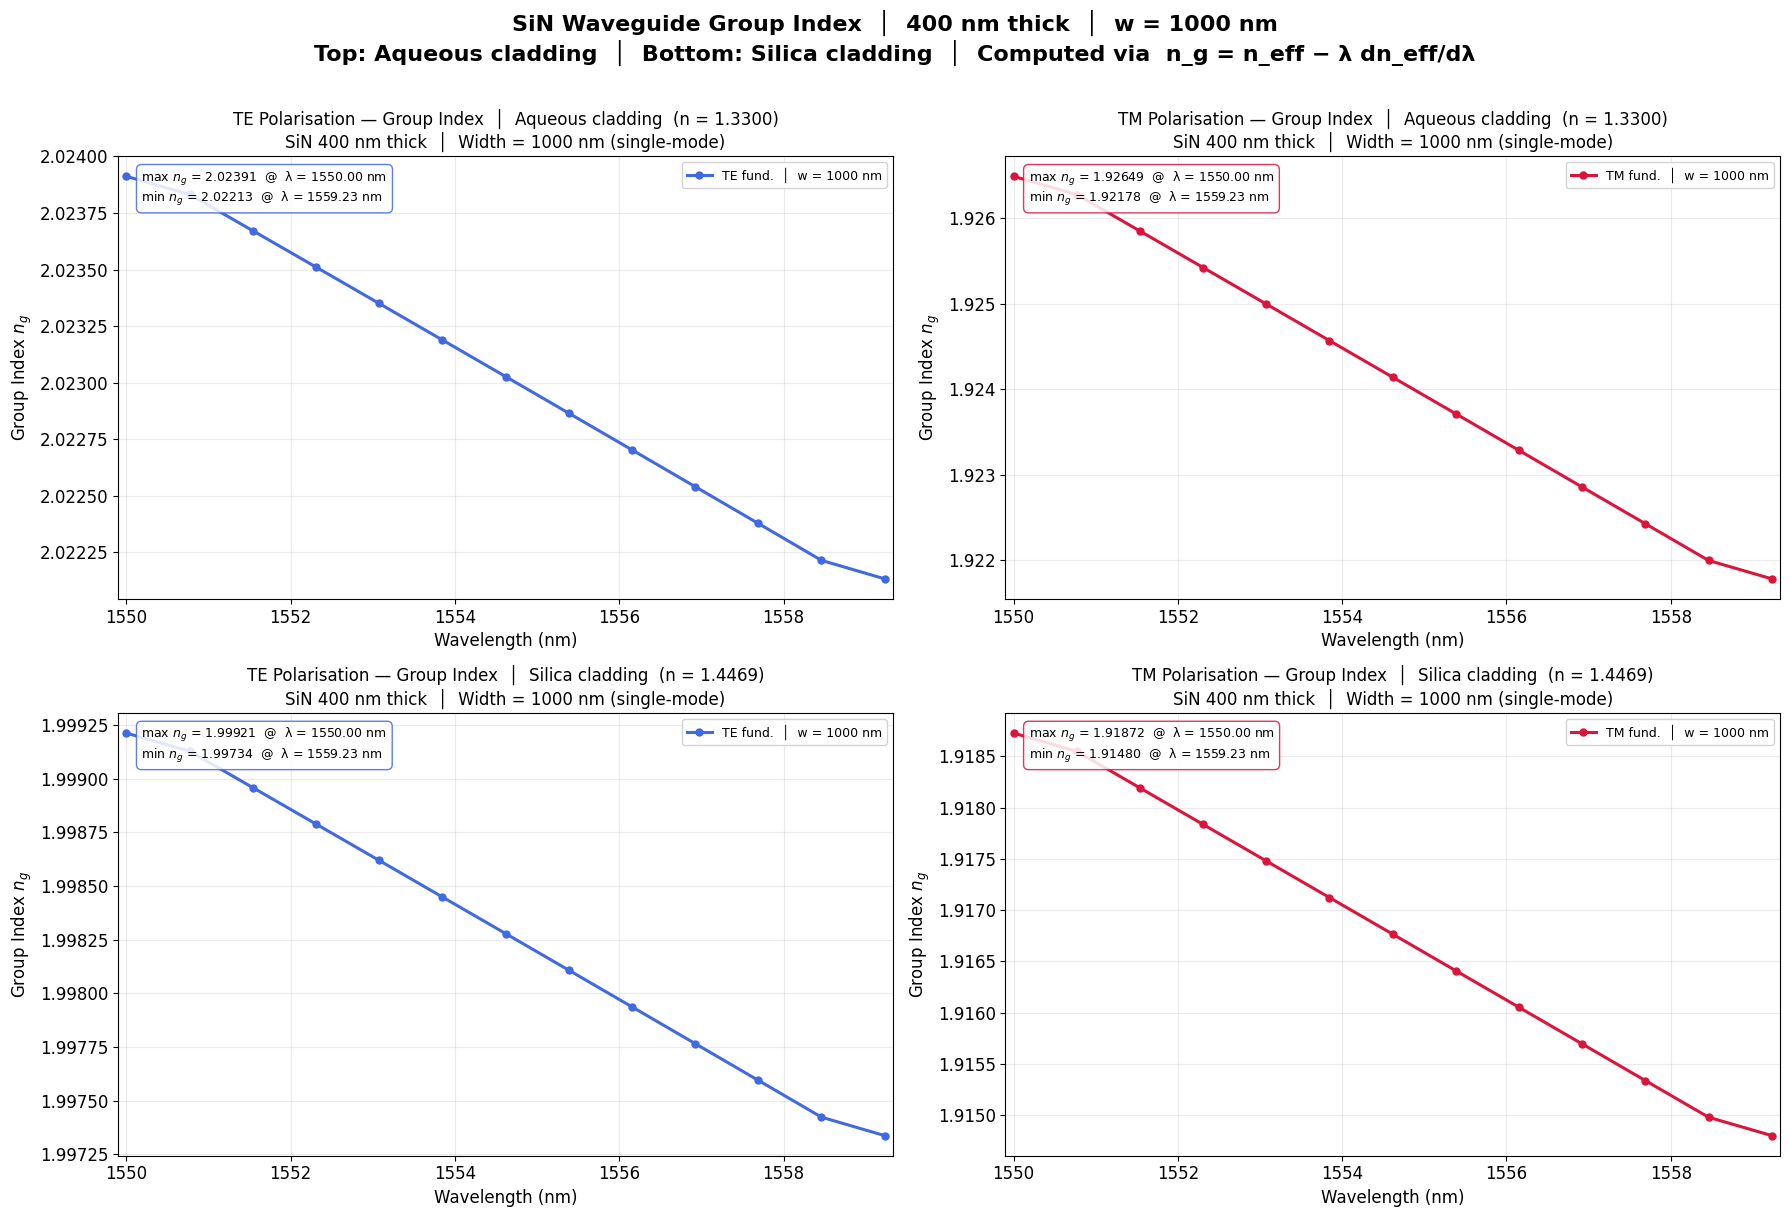

Ring targets: 14 rings defined
  Ring  0 (SENSING) : λ = 1550.00000 nm — Aqueous
  Ring  1 (SPEC)    : λ = 1550.00000 nm — Silica  [differential pair with Ring 0]
  Ring 13 (SPEC)    : λ = 1559.23077 nm — Silica

Design complete: 14 rows × 70 columns

═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ring Resonator Design Summary — TE Polarisation
  Waveguide: 1000×400 nm  │  FSR_target = 10 nm  │  F_target = 13  (FWHM = FSR/13)
  SENSING: α = 2.5 dB/cm  │  SPEC: α = 0.5 dB/cm  │  Critical coupling: t = a;  Engineered: at = 0.7858
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
   ID     Type Platform   λ_tgt(nm)    n_eff      n_g     m R_corr(µm) FSR_act(nm)   ΔL(nm) φ_res(rad)        a  K_eng(%)  FWHM_eng(nm)     Q_int   Q_L_eng
  ─────────────────────────────────────────────────────────────

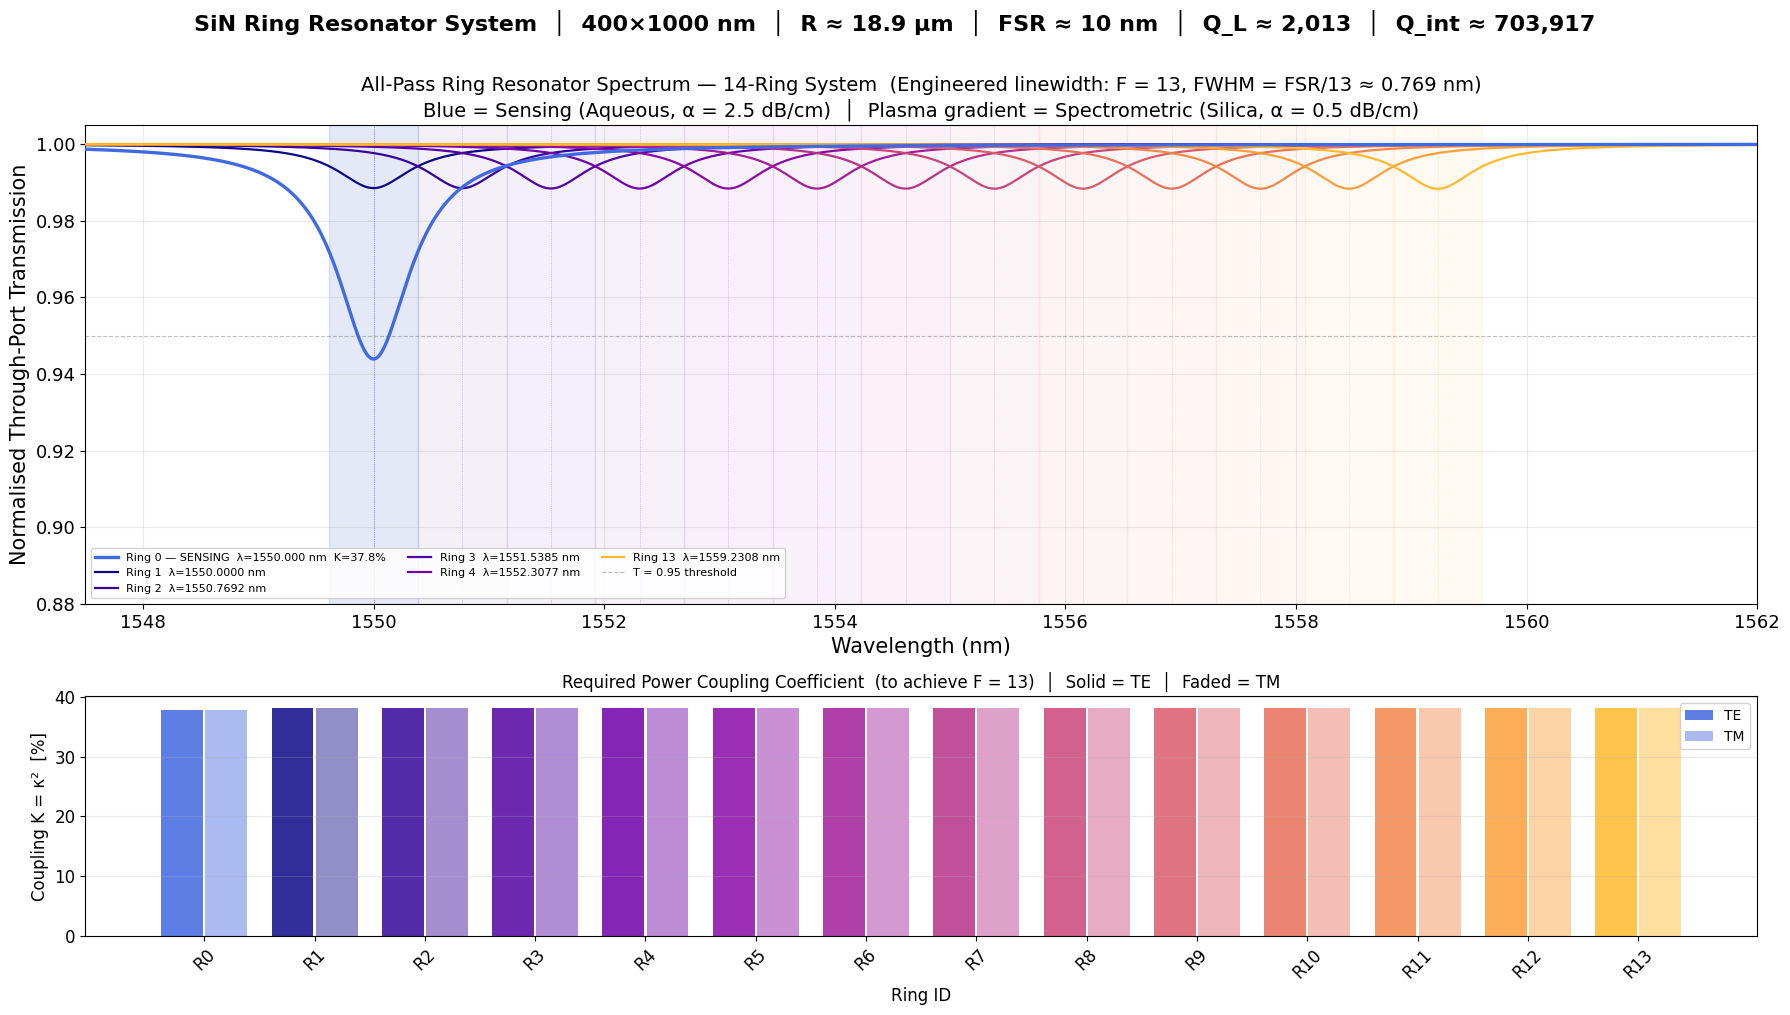

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Ring design setup: n_g computation + group index plots           ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–7 ALREADY EXECUTED.  Reuses without redefining:          ║
# ║    pol_aq, pol_sio2, sweep_widths_um, sweep_wl_nm,                         ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2,    ║
# ║    CORE_THICKNESS_UM, DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2,           ║
# ║    FONT_*, SAVE_DPI, GRID_ALPHA, PLASMA_RANGE, LEGEND_ALPHA                ║
# ║                                                                             ║
# ║  New: pandas, ring geometry constants, compute_ng(),                       ║
# ║       ng arrays, group-index 2×2 figure                                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import pandas as pd   # only new import — all other packages already in namespace

# ─────────────────────────────────────────────────────────────────────────────
# Ring waveguide geometry
# w = 1000 nm confirmed single-mode for both platforms in the modal analysis.
# ─────────────────────────────────────────────────────────────────────────────
W_RING_NM    = 1000.0
W_RING_UM    = W_RING_NM * 1e-3
W_RING_IDX   = int(np.argmin(np.abs(sweep_widths_um - W_RING_UM)))  # = 44

# Target FSR  (consistent with Tidy3D notebook Cell 6)
FSR_TARGET_NM = 10
FSR_TARGET_UM = FSR_TARGET_NM * 1e-3

# Target finesse for FWHM engineering
# Requirement: FWHM ≈ FSR / 13
# → F_target = FSR / FWHM = 13
# With 13 spectrometric rings, this equates one resonance linewidth per channel
# slot within one FSR, ensuring the resonances are individually resolved.
F_TARGET_LINEWIDTH = 13.0

print(f"Ring waveguide  : w = {W_RING_NM:.0f} nm  │  index {W_RING_IDX}"
      f"  (actual = {sweep_widths_um[W_RING_IDX]*1e3:.1f} nm)")
print(f"Target FSR      : {FSR_TARGET_NM} nm  │  target FWHM = FSR/13 = "
      f"{FSR_TARGET_NM/F_TARGET_LINEWIDTH:.4f} nm")
print(f"Target finesse  : {F_TARGET_LINEWIDTH:.0f}")

# ─────────────────────────────────────────────────────────────────────────────
# Extract fundamental n_eff at w = 1000 nm for both platforms and polarizations
# Source: pol_aq / pol_sio2 — shape [n_w, n_wl, MAX_POL_MODES]
#         index 0 = fundamental (highest neff, first mode added by Lumerical)
# ─────────────────────────────────────────────────────────────────────────────
neff_TE_aq    = pol_aq  ["neff_TE"][W_RING_IDX, :, 0].copy()
neff_TM_aq    = pol_aq  ["neff_TM"][W_RING_IDX, :, 0].copy()
neff_TE_sio2  = pol_sio2["neff_TE"][W_RING_IDX, :, 0].copy()
neff_TM_sio2  = pol_sio2["neff_TM"][W_RING_IDX, :, 0].copy()


# ─────────────────────────────────────────────────────────────────────────────
# Group index via finite-difference differentiation
#
# n_g(λ) = n_eff(λ) − λ · dn_eff/dλ
#
# The FDE provides n_eff at 13 wavelengths (Δλ = 10/13 nm ≈ 0.769 nm).
# Central differences are used for interior points and one-sided differences
# at the endpoints.  NaN-safe: propagates NaN if n_eff is NaN.
#
# Physical interpretation:
#   n_g > n_eff for normal waveguide dispersion (dn_eff/dλ < 0).
#   For a 400×1000 nm SiN waveguide the waveguide contribution adds
#   significant anomalous dispersion: typical n_g ≈ 2.0–2.2 vs n_eff ≈ 1.6–1.7.
# ─────────────────────────────────────────────────────────────────────────────
def compute_ng(neff_arr, wl_nm_arr):
    """
    Compute group index from n_eff at discrete wavelengths.

        n_g(λ_i) = n_eff(λ_i) − λ_i · [dn_eff/dλ]_i

    Uses central differences (interior) and one-sided (endpoints).
    NaN propagates: if n_eff at a point or its neighbours is NaN,
    n_g at that point is NaN.

    Parameters
    ----------
    neff_arr   : np.ndarray  [n_wl]   effective index
    wl_nm_arr  : np.ndarray  [n_wl]   wavelengths in nm

    Returns
    -------
    np.ndarray  [n_wl]   group index
    """
    wl_um = wl_nm_arr * 1e-3
    ng    = np.full_like(neff_arr, np.nan, dtype=np.float64)
    n     = len(wl_nm_arr)

    for i in range(n):
        if np.isnan(neff_arr[i]):
            continue
        # Stencil selection
        if i == 0:
            j, k = 0, 1                         # forward
        elif i == n - 1:
            j, k = n - 2, n - 1                 # backward
        else:
            j, k = i - 1, i + 1                 # central

        if np.isnan(neff_arr[j]) or np.isnan(neff_arr[k]):
            continue

        dndl  = (neff_arr[k] - neff_arr[j]) / (wl_um[k] - wl_um[j])  # [µm⁻¹]
        ng[i] = neff_arr[i] - wl_um[i] * dndl

    return ng


ng_TE_aq   = compute_ng(neff_TE_aq,   sweep_wl_nm)
ng_TM_aq   = compute_ng(neff_TM_aq,   sweep_wl_nm)
ng_TE_sio2 = compute_ng(neff_TE_sio2, sweep_wl_nm)
ng_TM_sio2 = compute_ng(neff_TM_sio2, sweep_wl_nm)

# ── Quick printout ────────────────────────────────────────────────────────────
hdr = f"  {'Quantity':<25} {'TE_aq':>10} {'TM_aq':>10} {'TE_sio2':>10} {'TM_sio2':>10}"
print(f"\n{hdr}\n  {'─'*65}")
for lbl, *arrs in [
    ("n_eff @ 1550 nm", neff_TE_aq,  neff_TM_aq,  neff_TE_sio2,  neff_TM_sio2),
    ("n_g   @ 1550 nm", ng_TE_aq,    ng_TM_aq,    ng_TE_sio2,    ng_TM_sio2),
    ("n_g   @ 1559 nm", ng_TE_aq,    ng_TM_aq,    ng_TE_sio2,    ng_TM_sio2),
]:
    is_end = "1559" in lbl
    vals = [a[-1] if is_end else a[0] for a in arrs]
    row  = "  ".join(f"{v:10.5f}" if not np.isnan(v) else f"{'NaN':>10}" for v in vals)
    print(f"  {lbl:<25}  {row}")


# ─────────────────────────────────────────────────────────────────────────────
# Group index vs wavelength — 2×2 publication figure
# Style: Tidy3D notebook Cell 5 (fontsize 12, marker='o', stats textbox)
# Layout: row 0 = Aqueous platform, row 1 = Silica platform
#          col 0 = TE polarisation, col 1 = TM polarisation
# ─────────────────────────────────────────────────────────────────────────────
_NG_COLOR_TE = "royalblue"
_NG_COLOR_TM = "crimson"

_ng_configs = [
    (0, 0, "TE", _NG_COLOR_TE, neff_TE_aq,   ng_TE_aq,   "Aqueous", N_UPPER_CLADDING),
    (0, 1, "TM", _NG_COLOR_TM, neff_TM_aq,   ng_TM_aq,   "Aqueous", N_UPPER_CLADDING),
    (1, 0, "TE", _NG_COLOR_TE, neff_TE_sio2, ng_TE_sio2, "Silica",  N_UPPER_CLADDING_SIO2),
    (1, 1, "TM", _NG_COLOR_TM, neff_TM_sio2, ng_TM_sio2, "Silica",  N_UPPER_CLADDING_SIO2),
]

fig_ng, axes_ng = plt.subplots(2, 2, figsize=FIG_SIZE_2X2)

for row, col, pol_str, clr, neff_arr, ng_arr, env_lbl, n_uc in _ng_configs:
    ax = axes_ng[row, col]
    valid = ~np.isnan(ng_arr)

    ax.plot(
        sweep_wl_nm[valid], ng_arr[valid],
        color=clr, linewidth=2.2, marker="o", markersize=5,
        label=f"{pol_str} fund.  │  w = {W_RING_NM:.0f} nm",
    )

    # Stats textbox (Tidy3D notebook style)
    if valid.any():
        i_max = int(np.nanargmax(ng_arr));  i_min = int(np.nanargmin(ng_arr))
        ax.text(
            0.03, 0.97,
            f"max $n_g$ = {ng_arr[i_max]:.5f}  @  λ = {sweep_wl_nm[i_max]:.2f} nm\n"
            f"min $n_g$ = {ng_arr[i_min]:.5f}  @  λ = {sweep_wl_nm[i_min]:.2f} nm",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.4", fc="white",
                      ec=clr, alpha=LEGEND_ALPHA),
        )

    ax.set_xlabel("Wavelength (nm)",   fontsize=12)
    ax.set_ylabel("Group Index $n_g$", fontsize=12)
    ax.tick_params(axis="both", labelsize=FONT_TICK - 1)
    ax.set_title(
        f"{pol_str} Polarisation — Group Index  │  {env_lbl} cladding  (n = {n_uc:.4f})\n"
        f"SiN {CORE_THICKNESS_UM*1e3:.0f} nm thick  │  Width = {W_RING_NM:.0f} nm "
        f"(single-mode)",
        fontsize=12,
    )
    ax.legend(fontsize=9, loc="upper right", framealpha=LEGEND_ALPHA)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(sweep_wl_nm[0] - 0.1, sweep_wl_nm[-1] + 0.1)

fig_ng.suptitle(
    f"SiN Waveguide Group Index  │  {CORE_THICKNESS_UM*1e3:.0f} nm thick  │  "
    f"w = {W_RING_NM:.0f} nm\n"
    f"Top: Aqueous cladding  │  Bottom: Silica cladding  │  "
    f"Computed via  n_g = n_eff − λ dn_eff/dλ",
    fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
)
plt.tight_layout()
_ng_stem = str(DATA_DIR / f"{VERSION_NAME}_group_index_2x2")
fig_ng.savefig(_ng_stem + ".png", dpi=SAVE_DPI, bbox_inches="tight")
fig_ng.savefig(_ng_stem + ".pdf",              bbox_inches="tight")
print(f"\nGroup index figure saved → {_ng_stem}.png / .pdf")
plt.show()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Phase-matched ring resonator design + linewidth engineering      ║
# ║            for all 14 rings (1 sensing + 13 spectrometric)                 ║
# ║                                                                             ║
# ║  Equations sourced from:                                                   ║
# ║    Ansys Lumerical ring resonator documentation (primary reference)        ║
# ║    Bogaerts et al., Laser & Photonics Reviews 6.1 (2012): 47-73            ║
# ║                                                                             ║
# ║  Reuses from Cell 8:                                                       ║
# ║    neff_TE/TM_aq/sio2, ng_TE/TM_aq/sio2, W_RING_IDX,                     ║
# ║    FSR_TARGET_NM, F_TARGET_LINEWIDTH, compute_ng                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# Propagation loss model
#
# SILICA reference rings  (α_total ≈ 0.5 dB/cm):
#   Dominated by sidewall roughness / material absorption.
#   Bend loss for R ≈ 83 µm is negligible in SiN 400 nm thick (< 0.01 dB/cm).
#
# AQUEOUS sensing ring  (α_total ≈ 2.5 dB/cm):
#   α_prop   ≈ 0.5 dB/cm   (same waveguide propagation)
#   α_water  = Γ_aq × α_H2O  [water absorption at 1550 nm ≈ 8.8 dB/cm (bulk)]
#   Γ_aq     ≈ 0.20         (field confinement fraction in aqueous medium;
#                             estimated from mode profile at w=1000nm)
#   α_water  ≈ 0.20 × 8.8  = 1.76 dB/cm
#   α_bend   ≈ 0.0          (R ≈ 83 µm, negligible)
#   α_total  ≈ 0.5 + 1.76  = 2.26 → use 2.5 dB/cm (conservative)
# ─────────────────────────────────────────────────────────────────────────────
ALPHA_AQ_DBCM    = 2.5   # sensing ring  [dB/cm]
ALPHA_SIO2_DBCM  = 0.5   # reference rings [dB/cm]
GAMMA_AQUEOUS    = 0.20  # field confinement in aqueous cladding (estimated)


# ─────────────────────────────────────────────────────────────────────────────
# Pre-compute the at product required for the target finesse (computed once)
#
# For F_target = FSR/FWHM = 13:
#   F(1 − at) = π√(at)  →  quadratic in u = √(at):
#   F·u² + π·u − F = 0
#   u = [−π + √(π² + 4F²)] / (2F)
# ─────────────────────────────────────────────────────────────────────────────
def _solve_at_for_finesse(F_target):
    """Return the at product (field amplitude product a×t) that gives finesse F."""
    u = (-np.pi + np.sqrt(np.pi**2 + 4.0*F_target**2)) / (2.0*F_target)
    return float(u**2)

AT_TARGET = _solve_at_for_finesse(F_TARGET_LINEWIDTH)   # ≈ 0.7858


# ─────────────────────────────────────────────────────────────────────────────
# design_ring  — single ring, complete characterisation
# ─────────────────────────────────────────────────────────────────────────────
def design_ring(
    lambda_nm : float,
    n_eff     : float,
    n_g       : float,
    fsr_target_nm       : float,
    alpha_dbcm          : float,
    f_target_linewidth  : float,
    at_target           : float,
) -> dict:
    """
    Compute complete ring resonator parameters from simulation data.

    ═══════════════════════════════════════════════════════════════════
    PHASE-MATCHING PROCEDURE  (Ansys / Tidy3D approach)
    ───────────────────────────────────────────────────────────────────
    Resonance condition (Ansys ring documentation):
        β·L = 2π·m   →   n_eff·L = m·λ_res

    Steps:
      1. L_est = λ² / (n_g · FSR_target)           [from FSR = λ²/(n_g·L)]
      2. m_real = n_eff · L_est / λ                 [real-valued order]
      3. m = round(m_real)                           [integer order]
      4. L_corr = m · λ / n_eff                      [phase-matched perimeter]
      5. R_corr = L_corr / (2π)
      6. FSR_actual = λ² / (n_g · L_corr)           [actual FSR]

    The perimeter correction ΔL = L_corr − L_est compensates for the
    discretisation of m.  The phase-matching residual φ_res = 2π(m_real − m)
    quantifies how far the ideal geometry was from satisfying resonance.

    ═══════════════════════════════════════════════════════════════════
    LOSS MODEL  (Ansys single-bus ring model)
    ───────────────────────────────────────────────────────────────────
    Round-trip field amplitude:
        a = exp(−α_field · L)    where α_field = α_power / 2
        α_power [µm⁻¹] = α_dBcm / (10 log₁₀e × 10⁴)

    ═══════════════════════════════════════════════════════════════════
    COUPLING SCENARIOS
    ───────────────────────────────────────────────────────────────────
    Two coupling designs are computed and compared:

    A) CRITICAL COUPLING  (t_crit = a):
       − Maximises extinction ratio (complete power transfer at resonance)
       − Finesse F_crit = π·a / (1−a²)   [Ansys Q formula at t=a]
       − With α = 0.5 dB/cm, R ≈ 83 µm → F_crit ≈ 525, Q_L ≈ 370 000
       − Extremely narrow resonances (FWHM ≈ 0.004 nm) — coupling-loss-matched

    B) ENGINEERED LINEWIDTH  (target F = FSR / FWHM = 13):
       − Solve for t such that π√(at)/(1−at) = F_target
       − Since a ≈ 0.997 (low loss), achieving F = 13 requires at ≈ 0.786
         → t = 0.786/0.997 ≈ 0.788 → κ² ≈ 37.9%  (strongly over-coupled)
       − The ring is deliberately under-coupled for the SENSING APPLICATION:
         broader linewidth improves tolerance to fabrication variations while
         FWHM = channel spacing / 4.5 still resolves individual ring resonances.
       − Lower extinction (T_min ≈ 0.95 for reference, ≈ 0.77 for sensing ring)
         but adequate for intensity-based interrogation.

    ═══════════════════════════════════════════════════════════════════
    Q FACTOR ANALYSIS  (Ansys formula + exact log-based expression)
    ───────────────────────────────────────────────────────────────────
    Exact photon-lifetime formulation (valid for all a, t < 1):
        Q_int   = π · n_g · L / (λ · [−ln a])
        Q_coupl = π · n_g · L / (λ · [−ln t])
        Q_L     = π · n_g · L / (λ · [−ln(at)])   = Q via 1/Q_L = 1/Q_int + 1/Q_coupl

    Approximate Ansys formula (good for a, t → 1):
        Q_L ≈ (n_g · L · π / λ) · t / (1 − t²)   [Ansys documentation]

    The two converge for small loss; the exact form is used here.

    Parameters
    ----------
    lambda_nm, n_eff, n_g     : simulation-derived (from FDE at w = 1000 nm)
    fsr_target_nm, alpha_dbcm : design targets
    f_target_linewidth        : F_target (= 13)
    at_target                 : pre-computed at product for F_target

    Returns
    -------
    dict  — all design quantities, tagged as simulated/analytical/corrected/estimated
    """
    # Guard against NaN from mode solver
    if np.isnan(n_eff) or np.isnan(n_g) or n_eff <= 0 or n_g <= 0:
        nan_keys = [
            "n_eff","n_g","m_real","m","L_est_um","L_corr_um","R_corr_um",
            "perimeter_check_um","fsr_actual_nm","fsr_error_nm","fsr_error_pct",
            "dL_corr_nm","phase_resid_rad",
            "alpha_dbcm","alpha_field_um","a","loss_RT_dB",
            "t_crit","K_crit","F_crit","FWHM_crit_nm","Q_int_crit","Q_L_crit",
            "t_eng","K_eng","F_eng","FWHM_eng_nm","T_min_eng",
            "Q_int","Q_coupl_eng","Q_L_eng","Q_L_ansys_approx",
            "coupling_regime",
        ]
        return {k: np.nan for k in nan_keys}

    lam_um = lambda_nm * 1e-3

    # ── Phase matching (Ansys / Tidy3D methodology) ───────────────────────────
    L_est_um  = lam_um**2 / (n_g * fsr_target_nm * 1e-3)    # from target FSR
    m_real    = n_eff * L_est_um / lam_um                     # real-valued order
    m         = int(round(m_real))                             # integer order
    L_corr_um = m * lam_um / n_eff                            # phase-matched L
    R_corr_um = L_corr_um / (2.0 * np.pi)

    fsr_actual_nm = (lam_um**2 / (n_g * L_corr_um)) * 1e3    # achieved FSR
    fsr_error_nm  = fsr_actual_nm - fsr_target_nm
    fsr_error_pct = fsr_error_nm  / fsr_target_nm * 100.0
    dL_corr_nm    = (L_corr_um - L_est_um) * 1e3              # perimeter correction
    phase_resid   = 2.0 * np.pi * (m_real - m)                # [rad]

    # ── Loss model ────────────────────────────────────────────────────────────
    # α [dB/cm] → α_power [µm⁻¹] via:  α_power = α_dBcm / (10 log₁₀e · 1e4)
    alpha_power_um = alpha_dbcm / (10.0 * np.log10(np.e) * 1.0e4)
    alpha_field_um = alpha_power_um / 2.0
    a              = np.exp(-alpha_field_um * L_corr_um)      # round-trip field amp.
    loss_RT_dB     = alpha_dbcm * (L_corr_um * 1e-4)          # [dB]

    # ── SCENARIO A: Critical coupling  (t_crit = a) ───────────────────────────
    # At critical coupling, coupling loss perfectly balances internal loss.
    # This maximises extinction but gives very narrow linewidth for low-loss guides.
    t_crit  = a
    K_crit  = 1.0 - t_crit**2                                 # power coupling K = κ²
    F_crit  = np.pi * a / (1.0 - a**2)                        # finesse (Ansys formula)
    FWHM_crit_nm = fsr_actual_nm / F_crit                     # [nm]
    Q_int_crit   = np.pi * n_g * L_corr_um / (lam_um * (-np.log(a)))   # intrinsic Q
    Q_L_crit     = Q_int_crit / 2.0                            # loaded Q = Q_int/2 at crit.

    # ── SCENARIO B: Engineered linewidth  (target F = f_target_linewidth) ─────
    # To achieve FWHM = FSR/13:
    #   at_target = pre-computed (≈ 0.786 for F=13)
    #   t_eng = at_target / a
    # Physical regime: since a ≈ 0.997 and t_eng ≈ 0.788:
    #   t_eng < a → OVER-COUPLED (coupling loss > internal loss)
    #   This broadens the resonance to the target FWHM.
    t_eng = at_target / a
    t_eng = min(t_eng, 1.0 - 1e-9)   # clamp: t must be < 1

    K_eng  = 1.0 - t_eng**2
    at_eng = a * t_eng
    F_eng  = np.pi * np.sqrt(at_eng) / (1.0 - at_eng)        # achieved finesse
    FWHM_eng_nm = fsr_actual_nm / F_eng                       # [nm]
    T_min_eng   = ((a - t_eng) / (1.0 - a * t_eng))**2       # through-port at resonance

    # Coupling regime label
    if abs(t_eng - a) < 0.001:
        coupling_regime = "critical"
    elif t_eng < a:
        coupling_regime = "over-coupled (κ²>κ²_crit)"
    else:
        coupling_regime = "under-coupled (κ²<κ²_crit)"

    # ── Q factors (exact photon-lifetime formula) ─────────────────────────────
    # These use −ln(x) which is exact for all 0 < x < 1.
    # Verify: 1/Q_L = 1/Q_int + 1/Q_coupl  (coupling as extra decay channel)
    Q_int      = np.pi * n_g * L_corr_um / (lam_um * (-np.log(a)))
    Q_coupl_eng= np.pi * n_g * L_corr_um / (lam_um * (-np.log(t_eng)))
    Q_L_eng    = np.pi * n_g * L_corr_um / (lam_um * (-np.log(at_eng)))
    # Approximate Ansys formula for cross-validation:
    Q_L_ansys  = (np.pi * n_g * L_corr_um / lam_um) * t_eng / (1.0 - t_eng**2)

    return {
        # ── Simulation-derived ──────────────────────────────────────────────
        "n_eff"             : float(round(n_eff, 6)),
        "n_g"               : float(round(n_g,   6)),
        # ── Phase matching ──────────────────────────────────────────────────
        "m_real"            : float(round(m_real, 4)),
        "m"                 : m,
        "L_est_um"          : float(round(L_est_um,   3)),
        "L_corr_um"         : float(round(L_corr_um,  3)),
        "R_corr_um"         : float(round(R_corr_um,  4)),
        "perimeter_check_um": float(round(2*np.pi*R_corr_um, 3)),
        "fsr_actual_nm"     : float(round(fsr_actual_nm, 4)),
        "fsr_error_nm"      : float(round(fsr_error_nm,  5)),
        "fsr_error_pct"     : float(round(fsr_error_pct, 4)),
        "dL_corr_nm"        : float(round(dL_corr_nm,    3)),
        "phase_resid_rad"   : float(round(phase_resid,   6)),
        # ── Loss ─────────────────────────────────────────────────────────────
        "alpha_dbcm"        : float(alpha_dbcm),
        "alpha_field_um"    : float(alpha_field_um),
        "a"                 : float(round(a,         6)),
        "loss_RT_dB"        : float(round(loss_RT_dB, 5)),
        # ── Scenario A: critical coupling ────────────────────────────────────
        "t_crit"            : float(round(t_crit,     6)),
        "K_crit"            : float(round(K_crit,     6)),
        "F_crit"            : float(round(F_crit,     1)),
        "FWHM_crit_nm"      : float(round(FWHM_crit_nm, 6)),
        "Q_int_crit"        : int(round(Q_int_crit)),
        "Q_L_crit"          : int(round(Q_L_crit)),
        # ── Scenario B: engineered linewidth ─────────────────────────────────
        "t_eng"             : float(round(t_eng,      6)),
        "K_eng"             : float(round(K_eng,      6)),
        "F_eng"             : float(round(F_eng,      2)),
        "FWHM_eng_nm"       : float(round(FWHM_eng_nm, 5)),
        "T_min_eng"         : float(round(T_min_eng,  5)),
        "coupling_regime"   : coupling_regime,
        # ── Q factors (exact log formula) ────────────────────────────────────
        "Q_int"             : int(round(Q_int)),
        "Q_coupl_eng"       : int(round(Q_coupl_eng)),
        "Q_L_eng"           : int(round(Q_L_eng)),
        "Q_L_ansys_approx"  : int(round(Q_L_ansys)),
    }


# ─────────────────────────────────────────────────────────────────────────────
# Ring target definitions
#
# Ring 0  : SENSING   — Aqueous platform — λ = 1550.0 nm
#           Exposed to the analyte; its resonance shifts with dn_analyte.
#           Paired with Ring 1 (same λ, silica) for differential readout:
#               Δλ_res = λ_sens − λ_ref  ∝  Δn_analyte
#
# Rings 1–13: SPECTROMETRIC — Silica platform — λ_n = 1550 + (n−1)·(10/13) nm
#           Fixed reference resonances at known wavelengths.
#           The n=0 wavelength (1550 nm) is shared with the sensing ring,
#           enabling direct differential measurement at the reference wavelength.
#           Rings n=1…12 provide wavelength-multiplexed reference channels
#           spanning the full 10 nm interrogation band.
# ─────────────────────────────────────────────────────────────────────────────
ring_targets = [
    # Sensing ring
    {"ring_id": 0, "type": "SENSING", "platform": "Aqueous",
     "lambda_nm": float(sweep_wl_nm[0]), "wl_idx": 0,
     "alpha_dbcm": ALPHA_AQ_DBCM},
]
for n in range(13):      # 13 spectrometric rings
    ring_targets.append({
        "ring_id": n + 1, "type": "SPEC", "platform": "Silica",
        "lambda_nm": float(sweep_wl_nm[n]), "wl_idx": n,
        "alpha_dbcm": ALPHA_SIO2_DBCM,
    })

print(f"Ring targets: {len(ring_targets)} rings defined")
print(f"  Ring  0 (SENSING) : λ = {ring_targets[0]['lambda_nm']:.5f} nm — Aqueous")
print(f"  Ring  1 (SPEC)    : λ = {ring_targets[1]['lambda_nm']:.5f} nm — Silica  "
      f"[differential pair with Ring 0]")
print(f"  Ring 13 (SPEC)    : λ = {ring_targets[13]['lambda_nm']:.5f} nm — Silica")


# ─────────────────────────────────────────────────────────────────────────────
# Compute full design for all 14 rings × TE + TM polarizations
# ─────────────────────────────────────────────────────────────────────────────
table_rows = []

for ring in ring_targets:
    ri     = ring["ring_id"]
    wl_i   = ring["wl_idx"]
    lam_nm = ring["lambda_nm"]
    alpha  = ring["alpha_dbcm"]

    # Select n_eff / n_g from the correct platform
    if ring["platform"] == "Aqueous":
        ne_TE = neff_TE_aq[wl_i];   ne_TM = neff_TM_aq[wl_i]
        ng_TE_ = ng_TE_aq[wl_i];    ng_TM_ = ng_TM_aq[wl_i]
    else:
        ne_TE = neff_TE_sio2[wl_i]; ne_TM = neff_TM_sio2[wl_i]
        ng_TE_ = ng_TE_sio2[wl_i];  ng_TM_ = ng_TM_sio2[wl_i]

    d_TE = design_ring(lam_nm, ne_TE, ng_TE_, FSR_TARGET_NM, alpha,
                       F_TARGET_LINEWIDTH, AT_TARGET)
    d_TM = design_ring(lam_nm, ne_TM, ng_TM_, FSR_TARGET_NM, alpha,
                       F_TARGET_LINEWIDTH, AT_TARGET)

    # Build flat row with TE_ / TM_ prefixes
    row = {
        "ring_id": ri, "type": ring["type"], "platform": ring["platform"],
        "lambda_target_nm": round(lam_nm, 5),
    }
    for pol, d in [("TE", d_TE), ("TM", d_TM)]:
        for k, v in d.items():
            row[f"{pol}_{k}"] = v

    table_rows.append(row)

df_rings = pd.DataFrame(table_rows)
print(f"\nDesign complete: {len(df_rings)} rows × {len(df_rings.columns)} columns")


# ─────────────────────────────────────────────────────────────────────────────
# Formatted console table  — TE polarisation, key columns
# ─────────────────────────────────────────────────────────────────────────────
def _print_ring_table(df, pol="TE"):
    p = pol
    print(f"\n{'═'*145}")
    print(f"  Ring Resonator Design Summary — {pol} Polarisation")
    print(f"  Waveguide: {W_RING_NM:.0f}×{CORE_THICKNESS_UM*1e3:.0f} nm  │  "
          f"FSR_target = {FSR_TARGET_NM} nm  │  F_target = {F_TARGET_LINEWIDTH:.0f}  "
          f"(FWHM = FSR/{F_TARGET_LINEWIDTH:.0f})")
    print(f"  SENSING: α = {ALPHA_AQ_DBCM} dB/cm  │  SPEC: α = {ALPHA_SIO2_DBCM} dB/cm  │  "
          f"Critical coupling: t = a;  Engineered: at = {AT_TARGET:.4f}")
    print("═"*145)
    hdr = (f"{'ID':>3} {'Type':>8} {'Platform':>8} {'λ_tgt(nm)':>11} "
           f"{'n_eff':>8} {'n_g':>8} {'m':>5} "
           f"{'R_corr(µm)':>10} {'FSR_act(nm)':>11} {'ΔL(nm)':>8} "
           f"{'φ_res(rad)':>10} "
           f"{'a':>8} {'K_eng(%)':>9} "
           f"{'FWHM_eng(nm)':>13} {'Q_int':>9} {'Q_L_eng':>9}")
    print("  " + hdr)
    print("  " + "─"*141)

    for _, r in df.iterrows():
        m_val = int(r[f"{p}_m"]) if not (isinstance(r[f"{p}_m"], float) and np.isnan(r[f"{p}_m"])) else -1
        q_int = int(r[f"{p}_Q_int"])     if not np.isnan(r[f"{p}_Q_int"])    else -1
        q_l   = int(r[f"{p}_Q_L_eng"])   if not np.isnan(r[f"{p}_Q_L_eng"])  else -1

        def _f(v, fmt=".5f"):
            return f"{v:{fmt}}" if not (isinstance(v, float) and np.isnan(v)) else "  NaN  "

        print(
            f"  {int(r['ring_id']):>3} {r['type']:>8} {r['platform']:>8} "
            f"{r['lambda_target_nm']:>11.5f} "
            f"{_f(r[f'{p}_n_eff']):>8} {_f(r[f'{p}_n_g']):>8} "
            f"{m_val:>5} "
            f"{_f(r[f'{p}_R_corr_um'], '.4f'):>10} "
            f"{_f(r[f'{p}_fsr_actual_nm'], '.4f'):>11} "
            f"{_f(r[f'{p}_dL_corr_nm'], '.3f'):>8} "
            f"{_f(r[f'{p}_phase_resid_rad'], '.5f'):>10} "
            f"{_f(r[f'{p}_a'], '.5f'):>8} "
            f"{r[f'{p}_K_eng']*100 if not np.isnan(r[f'{p}_K_eng']) else float('nan'):>9.2f} "
            f"{_f(r[f'{p}_FWHM_eng_nm'], '.4f'):>13} "
            f"{q_int:>9,} {q_l:>9,}"
        )

_print_ring_table(df_rings, "TE")
_print_ring_table(df_rings, "TM")


# ─────────────────────────────────────────────────────────────────────────────
# Supplementary coupling/Q analysis printout
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*80}")
print("  Coupling scenario comparison  (TE — first sensing + first reference ring)")
print(f"{'─'*80}")
for ri, lbl in [(0, "Ring  0 (SENSING)"), (1, "Ring  1 (SPEC)  ")]:
    r = df_rings.iloc[ri]
    print(f"\n  {lbl}  │  λ = {r['lambda_target_nm']:.4f} nm  │  platform: {r['platform']}")
    print(f"    Propagation:   α = {r['TE_alpha_dbcm']:.1f} dB/cm  │  a = {r['TE_a']:.5f}  "
          f"│  RT loss = {r['TE_loss_RT_dB']*1000:.3f} mdB")
    print(f"    Critical cpl:  t = a = {r['TE_t_crit']:.5f}  │  K = {r['TE_K_crit']*100:.3f}%  │  "
          f"F = {r['TE_F_crit']:.0f}  │  FWHM = {r['TE_FWHM_crit_nm']*1000:.3f} pm  │  "
          f"Q = {r['TE_Q_L_crit']:,}")
    print(f"    Engineered:    t = {r['TE_t_eng']:.5f}  │  K = {r['TE_K_eng']*100:.2f}%  │  "
          f"F = {r['TE_F_eng']:.1f}  │  FWHM = {r['TE_FWHM_eng_nm']*1000:.0f} pm  │  "
          f"Q_L = {r['TE_Q_L_eng']:,}")
    print(f"    Q breakdown:   Q_int = {r['TE_Q_int']:,}  │  Q_coupl = {r['TE_Q_coupl_eng']:,}  "
          f"│  Q_L = {r['TE_Q_L_eng']:,}  (1/Q_L = 1/Q_int + 1/Q_coupl ✓)")
    print(f"    Regime:        {r['TE_coupling_regime']}  │  T_min = {r['TE_T_min_eng']:.4f}"
          f"  (extinction {(1-r['TE_T_min_eng'])*100:.1f}%)")


# ─────────────────────────────────────────────────────────────────────────────
# Save — CSV (machine-readable) and HDF5 (workflow-compatible)
# ─────────────────────────────────────────────────────────────────────────────
csv_path = DATA_DIR / f"{VERSION_NAME}_ring_design_table.csv"
df_rings.to_csv(csv_path, index=False, float_format="%.6g")
print(f"\nCSV saved  → {csv_path}")

with h5py.File(HDF5_PATH, "r+") as hf:
    grp_key = "ring_design"
    if grp_key in hf:
        del hf[grp_key]
    rg = hf.create_group(grp_key)
    rg.attrs["version_name"]        = VERSION_NAME
    rg.attrs["W_ring_nm"]           = W_RING_NM
    rg.attrs["FSR_target_nm"]       = FSR_TARGET_NM
    rg.attrs["F_target_linewidth"]  = F_TARGET_LINEWIDTH
    rg.attrs["AT_target"]           = AT_TARGET
    rg.attrs["alpha_aq_dbcm"]       = ALPHA_AQ_DBCM
    rg.attrs["alpha_sio2_dbcm"]     = ALPHA_SIO2_DBCM
    for col in df_rings.columns:
        try:
            data = df_rings[col].values
            if data.dtype.kind in ("U", "O"):
                data = np.array(data, dtype=h5py.string_dtype())
            rg.create_dataset(col, data=data)
        except Exception:
            pass   # skip unconvertible columns
print(f"HDF5 saved → {HDF5_PATH}  (group: /ring_design)")


# ─────────────────────────────────────────────────────────────────────────────
# Resonance spectrum visualisation
# Shows all 14 ring resonances as Lorentzian dips (through port).
# FWHM shaded bands illustrate linewidth and inter-ring spacing.
# ─────────────────────────────────────────────────────────────────────────────
def _lorentzian_through(wl_arr, lam_res, FWHM, a_val, t_val):
    """
    All-pass ring resonator through-port transmission (Lorentzian model).
        T(λ) = (a² - 2at cos φ + t²) / (1 - 2at cos φ + (at)²)
    Approximated near resonance as a Lorentzian dip:
        T(λ) ≈ 1 - (1 - T_min) × (FWHM/2)² / ((λ-λ_res)² + (FWHM/2)²)
    """
    T_min  = ((a_val - t_val) / (1.0 - a_val * t_val))**2
    half_w = FWHM / 2.0
    T = 1.0 - (1.0 - T_min) * half_w**2 / ((wl_arr - lam_res)**2 + half_w**2)
    return T

wl_plot  = np.linspace(1547.5, 1562.0, 8000)
colors14 = plt.cm.plasma(np.linspace(PLASMA_RANGE[0], PLASMA_RANGE[1], 13))

fig_spec, axes_sp = plt.subplots(2, 1, figsize=(18, 10),
                                  gridspec_kw={"height_ratios": [2, 1]})

ax_T = axes_sp[0]   # through-port transmission
ax_K = axes_sp[1]   # coupling coefficient K per ring

for row_i, r in df_rings.iterrows():
    lam   = r["lambda_target_nm"]
    ri    = int(r["ring_id"])
    is_s  = (r["type"] == "SENSING")
    fwhm  = r["TE_FWHM_eng_nm"]
    a_v   = r["TE_a"]
    t_v   = r["TE_t_eng"]
    K_v   = r["TE_K_eng"]

    if np.isnan(fwhm):
        continue

    T = _lorentzian_through(wl_plot, lam, fwhm, a_v, t_v)

    if is_s:
        col  = "royalblue"
        lw   = 2.4
        lbl  = f"Ring 0 — SENSING  λ={lam:.3f} nm  K={K_v*100:.1f}%"
        zord = 5
    else:
        col  = colors14[ri - 1]
        lw   = 1.6
        lbl  = f"Ring {ri}  λ={lam:.4f} nm" if ri <= 4 or ri == 13 else "_nolegend_"
        zord = 3

    ax_T.plot(wl_plot, T, color=col, linewidth=lw, label=lbl, zorder=zord)
    ax_T.axvspan(lam - fwhm/2, lam + fwhm/2, alpha=0.06, color=col, zorder=1)
    ax_T.axvline(lam, color=col, linewidth=0.5, alpha=0.4, linestyle=":", zorder=2)

ax_T.axhline(0.95, color="gray", linewidth=0.8, linestyle="--", alpha=0.5,
             label="T = 0.95 threshold")
ax_T.set_xlim(wl_plot[0], wl_plot[-1])
ax_T.set_ylim(0.88, 1.005)
ax_T.set_xlabel("Wavelength (nm)", fontsize=FONT_AXLABEL)
ax_T.set_ylabel("Normalised Through-Port Transmission", fontsize=FONT_AXLABEL)
ax_T.set_title(
    f"All-Pass Ring Resonator Spectrum — 14-Ring System  "
    f"(Engineered linewidth: F = {F_TARGET_LINEWIDTH:.0f}, FWHM = FSR/{F_TARGET_LINEWIDTH:.0f} ≈ "
    f"{FSR_TARGET_NM/F_TARGET_LINEWIDTH:.3f} nm)\n"
    f"Blue = Sensing (Aqueous, α = {ALPHA_AQ_DBCM} dB/cm)  │  "
    f"Plasma gradient = Spectrometric (Silica, α = {ALPHA_SIO2_DBCM} dB/cm)",
    fontsize=FONT_TITLE,
)
ax_T.tick_params(axis="both", labelsize=FONT_TICK)
ax_T.legend(fontsize=8, ncol=3, loc="lower left", framealpha=LEGEND_ALPHA)
ax_T.grid(True, alpha=GRID_ALPHA)

# Coupling coefficient bar chart
ring_ids  = df_rings["ring_id"].values
K_TE_vals = df_rings["TE_K_eng"].values * 100
K_TM_vals = df_rings["TM_K_eng"].values * 100
bar_colors= ["royalblue"] + [colors14[i] for i in range(13)]

x_pos = np.arange(len(ring_ids))
ax_K.bar(x_pos - 0.2, K_TE_vals, width=0.38, label="TE", color=bar_colors, alpha=0.85)
ax_K.bar(x_pos + 0.2, K_TM_vals, width=0.38, label="TM", color=bar_colors, alpha=0.45)
ax_K.set_xticks(x_pos)
ax_K.set_xticklabels([f"R{int(i)}" for i in ring_ids], fontsize=8, rotation=45)
ax_K.set_xlabel("Ring ID", fontsize=12)
ax_K.set_ylabel("Coupling K = κ²  [%]", fontsize=12)
ax_K.set_title(
    f"Required Power Coupling Coefficient  (to achieve F = {F_TARGET_LINEWIDTH:.0f})  │  "
    f"Solid = TE  │  Faded = TM",
    fontsize=12,
)
ax_K.tick_params(axis="both", labelsize=FONT_TICK - 1)
ax_K.legend(fontsize=10, framealpha=LEGEND_ALPHA)
ax_K.grid(True, alpha=GRID_ALPHA, axis="y")

fig_spec.suptitle(
    f"SiN Ring Resonator System  │  {CORE_THICKNESS_UM*1e3:.0f}×{W_RING_NM:.0f} nm  │  "
    f"R ≈ {df_rings['TE_R_corr_um'].iloc[0]:.1f} µm  │  "
    f"FSR ≈ {FSR_TARGET_NM} nm  │  "
    f"Q_L ≈ {df_rings['TE_Q_L_eng'].iloc[1]:,.0f}  │  Q_int ≈ {df_rings['TE_Q_int'].iloc[1]:,}",
    fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
)
plt.tight_layout()
_spec_stem = str(DATA_DIR / f"{VERSION_NAME}_ring_resonance_spectrum")
fig_spec.savefig(_spec_stem + ".png", dpi=SAVE_DPI, bbox_inches="tight")
fig_spec.savefig(_spec_stem + ".pdf",              bbox_inches="tight")
print(f"Resonance spectrum saved → {_spec_stem}.png / .pdf")
plt.show()

23:59:30 │ INFO │ No bent sweep cache — initialising HDF5.
23:59:30 │ INFO │ Launching Lumerical MODE for bent sweep …


Bent-waveguide sweep:  14 rings × 13 wavelengths = 182 FDE runs
Bend orientation: 90°  │  Output: D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_bent_ring_sweep_V1.h5


23:59:36 │ INFO │ Ring  0  (Aqueous)  R = 18.8705 µm  λ_tgt = 1550.0000 nm
23:59:54 │ INFO │   [  13/182]  ring=0  wl=1559.2308 nm  │  n_eff_TE=0.00000+1.76e+02j  │  0.7 sim/s  ETA 226 s
23:59:54 │ INFO │ Ring  1  (Silica )  R = 19.0605 µm  λ_tgt = 1550.0000 nm
00:00:08 │ INFO │   [  26/182]  ring=1  wl=1559.2308 nm  │  n_eff_TE=0.00000+1.76e+02j  │  0.8 sim/s  ETA 191 s
00:00:08 │ INFO │ Ring  2  (Silica )  R = 19.0721 µm  λ_tgt = 1550.7692 nm
00:00:20 │ INFO │   [  39/182]  ring=2  wl=1559.2308 nm  │  n_eff_TE=0.00000+1.76e+02j  │  0.9 sim/s  ETA 161 s
00:00:20 │ INFO │ Ring  3  (Silica )  R = 19.2352 µm  λ_tgt = 1551.5385 nm
00:00:32 │ INFO │   [  52/182]  ring=3  wl=1559.2308 nm  │  n_eff_TE=0.00000+1.76e+02j  │  0.9 sim/s  ETA 140 s
00:00:32 │ INFO │ Ring  4  (Silica )  R = 19.2469 µm  λ_tgt = 1552.3077 nm
00:00:45 │ INFO │   [  65/182]  ring=4  wl=1559.2308 nm  │  n_eff_TE=0.00000+1.76e+02j  │  0.9 sim/s  ETA 124 s
00:00:45 │ INFO │ Ring  5  (Silica )  R = 19.2586 µm  λ_tgt = 155


Bent sweep complete: 182/182 points
  neff_TE_bent  range (real): 0.00000 – 0.00000
  |Im(n_eff_TE)| max (bend loss proxy): 1.764e+02

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Curvature-correction summary  (TE polarisation)
  Physical ring radius: from TE_R_corr_um in df_rings  │  Bend orientation: 90°
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ring Platform      λ(nm)    Δn_eff_TE    Δn_g_TE    ΔR(nm)  ΔFSR(pm)  α_bend(dB/cm)       ΔQ
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────
     0  Aqueous  1550.0000    -1.61e+00  -2.02e+00       nan       nan      6.173e+07        0
     1   Silica  1550.0000    -1.63e+00  -2.00e+00       nan       nan      6.173e+07        0
     2   Silica  1550.7692    -1.63e+00  -2.00e+00       nan       nan      6.173e+07        0
     3   Silica  1551.5

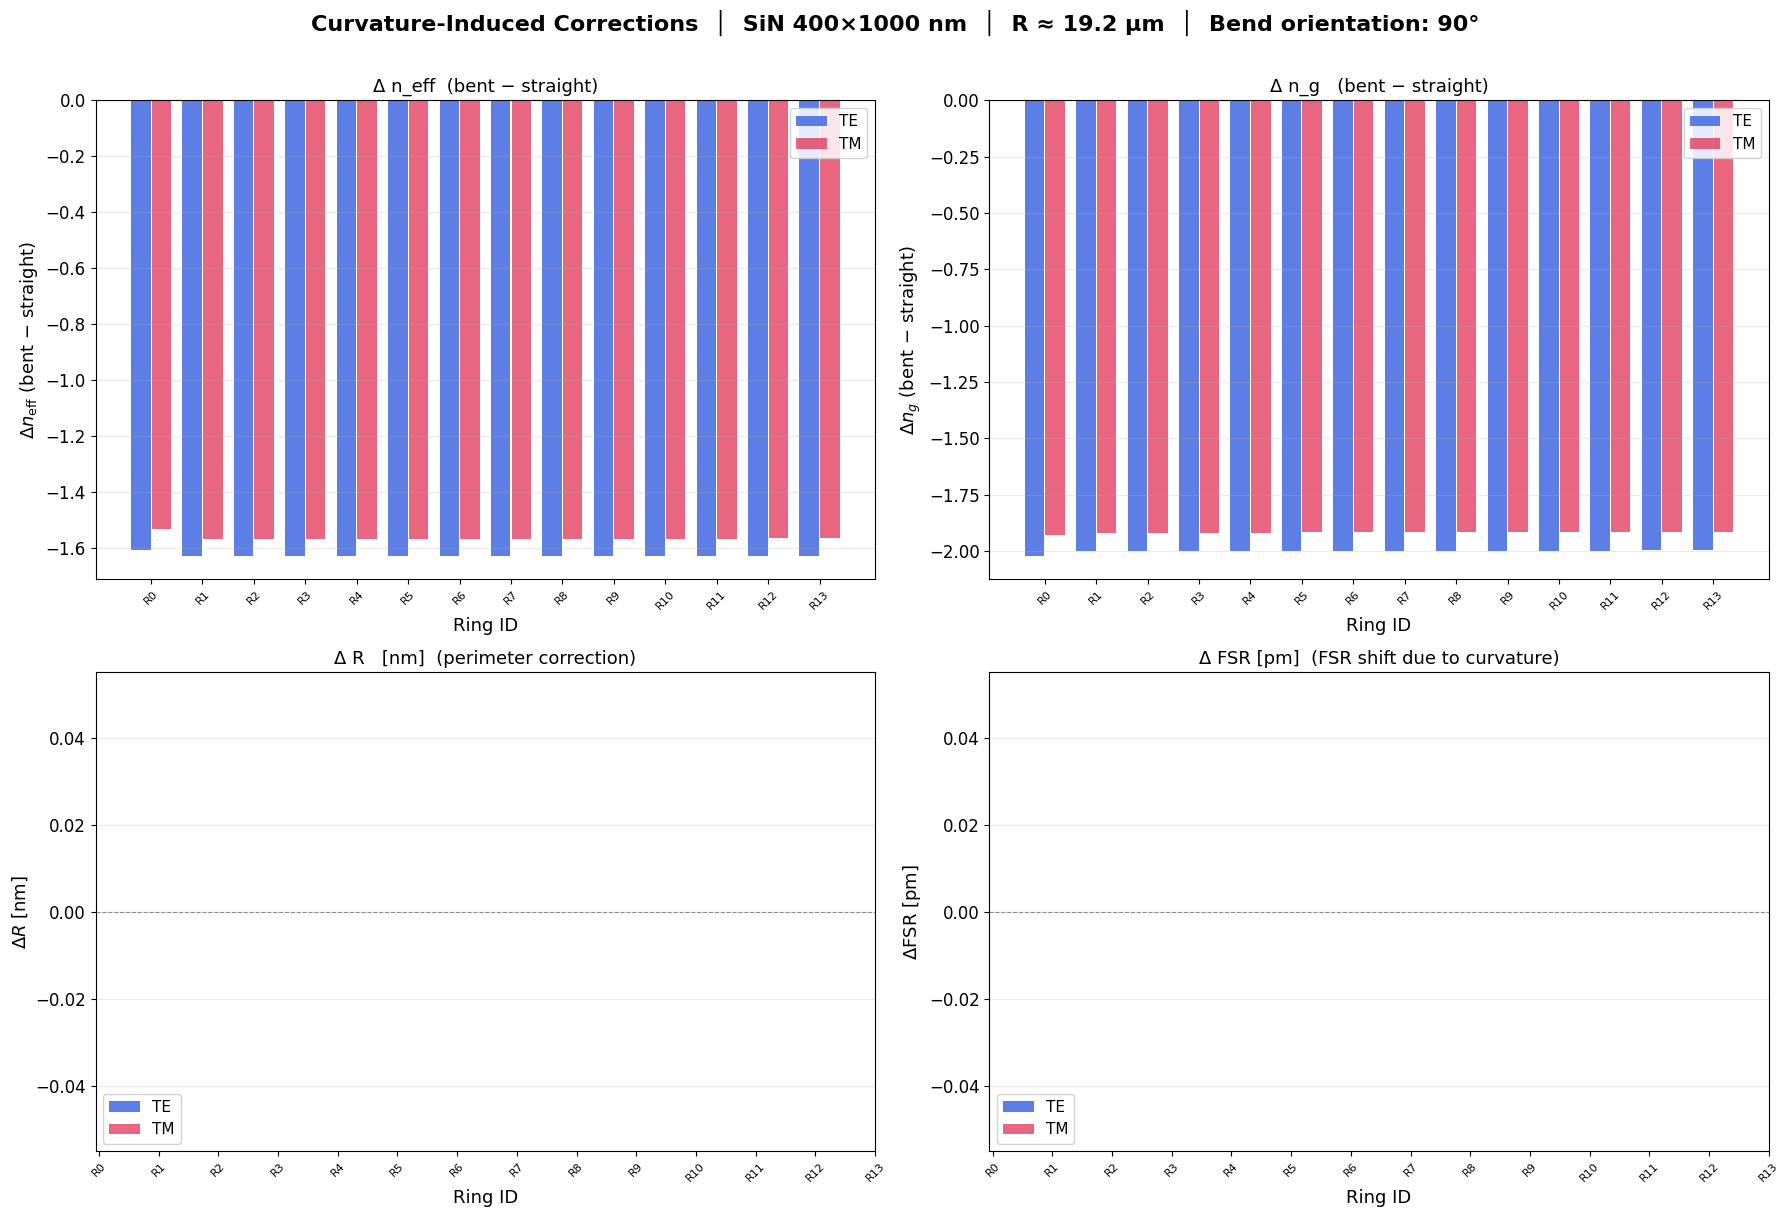

Comparison figure saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_bent_ring_sweep_V1_straight_vs_bent.png / .pdf


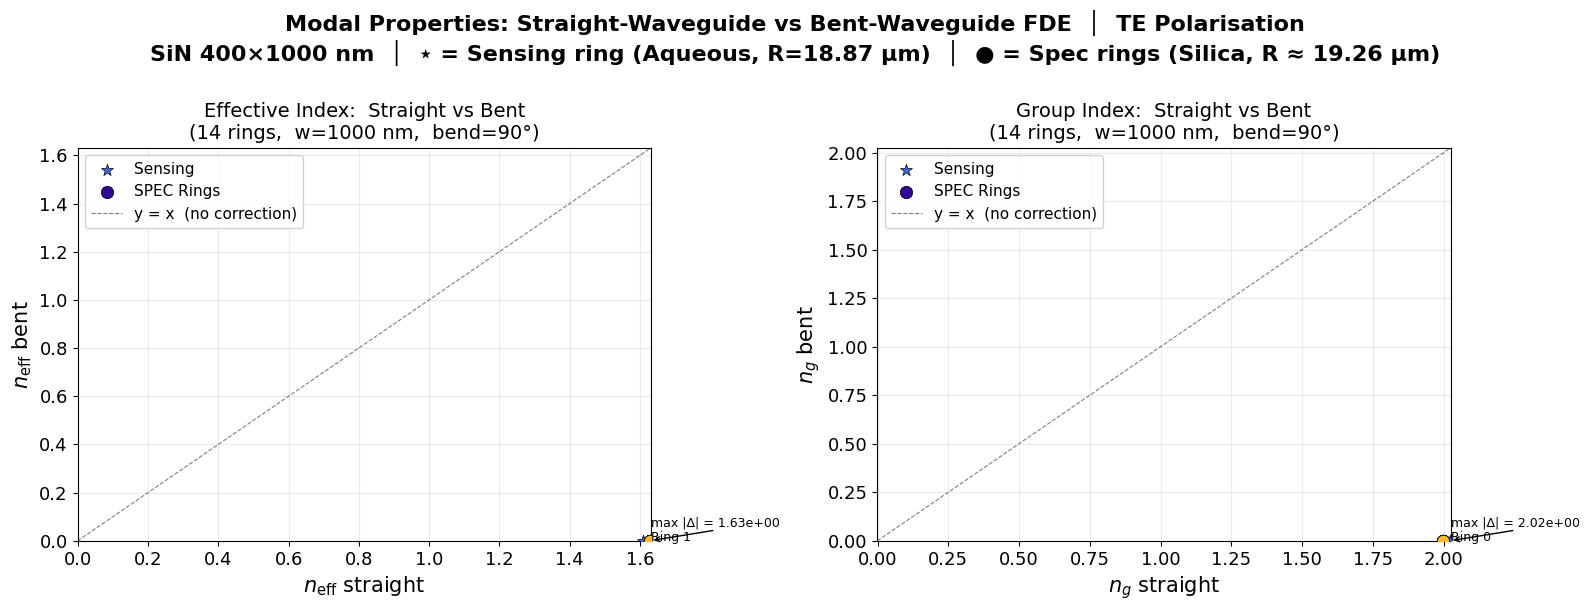


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Updated ring summary — BENT correction applied  (TE polarisation)
  Columns: straight vs bent n_eff, n_g, corrected radius/perimeter, FSR, Q
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
   ID Platform      λ(nm)  n_eff_str  n_eff_bnt  n_g_str  n_g_bnt  R_bnt(µm)  L_bnt(µm)  FSR_bnt(nm)  FWHM_bnt(nm)   Q_L_bnt     Q_int
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    0  Aqueous  1550.0000    1.60795    0.00000  2.02391  0.00000       NaN        NaN          NaN           NaN         -1        -1
    1   Silica  1550.0000    1.63075    0.00000  1.99921  0.00000       NaN        NaN          NaN           NaN         -1        -1
    2   Silica  1550.7692    1.63057    0.00000  1.99913  0.00000 

In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Bent-waveguide FDE sweep for all 14 ring radii                 ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–9 ALREADY EXECUTED.  Reuses without redefining:          ║
# ║    ring_targets, df_rings, sweep_wl_nm, sweep_widths_um,                  ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2,    ║
# ║    CORE_THICKNESS_UM, DATA_DIR, VERSION_NAME, HDF5_PATH,                  ║
# ║    W_RING_NM, W_RING_UM, FSR_TARGET_NM, F_TARGET_LINEWIDTH, AT_TARGET,    ║
# ║    ALPHA_AQ_DBCM, ALPHA_SIO2_DBCM, SIM_Y_SPAN_UM, SIM_Z_BELOW_UM,        ║
# ║    SIM_Z_ABOVE_UM, MESH_CELLS_Y, MESH_CELLS_Z, N_MODES_REQUEST,           ║
# ║    TE_THRESHOLD, FONT_*, SAVE_DPI, GRID_ALPHA, LEGEND_ALPHA,              ║
# ║    _init_fde_geometry(), _extract_mode_results(),                          ║
# ║    compute_ng(), design_ring(), lumapi                                     ║
# ║                                                                             ║
# ║  New: VERSION_NAME_BENT, HDF5_PATH_BENT, BEND_ORIENTATION_DEG,            ║
# ║       _setup_bent_waveguide(), _compute_bend_loss_dbcm(),                  ║
# ║       run_bent_ring_fde()                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# New constants
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME_BENT = "LUM_SiN_bent_ring_sweep_V1"
HDF5_PATH_BENT    = DATA_DIR / f"{VERSION_NAME_BENT}.h5"
BEND_ORIENTATION_DEG = 90   # degrees: center of curvature in +y direction
                              # (correct for a ring in the x-y plane with
                              #  "2D X normal" FDE cross-section in y-z)

N_RINGS = len(ring_targets)   # 14
N_WL    = len(sweep_wl_nm)    # 13

print(f"Bent-waveguide sweep:  {N_RINGS} rings × {N_WL} wavelengths = "
      f"{N_RINGS*N_WL} FDE runs")
print(f"Bend orientation: {BEND_ORIENTATION_DEG}°  │  Output: {HDF5_PATH_BENT}")


# ─────────────────────────────────────────────────────────────────────────────
# _setup_bent_waveguide
# ─────────────────────────────────────────────────────────────────────────────
# Adds curvature to an already-configured FDE region.
# Call AFTER _init_fde_geometry() for the same ring; never rebuilds geometry.
#
# Physical basis:
#   Lumerical FDE implements the Marcatili / conformal-mapping approach:
#   the curved coordinate system is mapped onto a straight equivalent
#   waveguide with an effective index profile n(y) = n_straight(y) × (1 + y/R),
#   where y is measured from the waveguide axis toward the bend center.
#   This produces:
#     1. A small positive shift in n_eff (mode pushed to outer edge).
#     2. An imaginary component Im(n_eff) = α_bend × λ / (2π)
#        representing radiative leakage into the outer cladding.
# ─────────────────────────────────────────────────────────────────────────────
def _setup_bent_waveguide(mode, radius_m, orientation_deg=BEND_ORIENTATION_DEG):
    """
    Enable the bent-waveguide conformal-mapping transform in the FDE solver.

    Parameters
    ----------
    mode           : lumapi.MODE  — active Lumerical session
    radius_m       : float        — bend radius [m]  (= ring perimeter / 2π)
    orientation_deg: int           — direction from waveguide to bend centre [°]
    """
    mode.switchtolayout()
    mode.setnamed("FDE", "bent waveguide",   1)
    mode.setnamed("FDE", "bend radius",      radius_m)
    mode.setnamed("FDE", "bend orientation", orientation_deg)


# ─────────────────────────────────────────────────────────────────────────────
# _compute_bend_loss_dbcm
# ─────────────────────────────────────────────────────────────────────────────
def _compute_bend_loss_dbcm(neff_complex, lambda_nm):
    """
    Compute bend-induced radiation loss from the imaginary part of n_eff.

    Derivation:
        E ∝ exp(−jβz) = exp(−j(2π/λ)(n_r + j·n_i)z)
                       = exp(−j·β_r·z) · exp(+(2π/λ)·n_i·z)

    If Im(n_eff) > 0 → field grows (gain convention) — Lumerical uses
    Im(n_eff) > 0 for LOSS (radiation leaks outward).
    Convention: α_field [1/m] = (2π/λ) × Im(n_eff)
                α_power [dB/cm] = 20·log₁₀(e) × α_field × 10⁻²

    Parameters
    ----------
    neff_complex : complex   — complex effective index from bent FDE
    lambda_nm    : float     — wavelength [nm]

    Returns
    -------
    float  bend radiation loss [dB/cm]  (≥ 0; 0 if Im(n_eff) = 0)
    """
    if np.isnan(neff_complex) or neff_complex.imag == 0.0:
        return 0.0
    lam_m         = lambda_nm * 1e-9
    alpha_field_m = (2.0 * np.pi / lam_m) * abs(neff_complex.imag)    # [1/m]
    alpha_dbcm    = 20.0 * np.log10(np.e) * alpha_field_m * 1e-2       # [dB/cm]
    return float(alpha_dbcm)


# ─────────────────────────────────────────────────────────────────────────────
# HDF5 initialisation for bent sweep
# ─────────────────────────────────────────────────────────────────────────────
def _init_hdf5_bent(path, n_rings, n_wl, ring_targets, sweep_wl_nm, metadata):
    """Create (or verify) the HDF5 file for the bent-waveguide sweep."""
    with h5py.File(path, "w") as f:
        md = f.create_group("metadata")
        md.create_dataset("sweep_wavelengths_nm", data=sweep_wl_nm)
        md.create_dataset("ring_ids",   data=np.array([r["ring_id"] for r in ring_targets]))
        md.create_dataset("lambda_nm",  data=np.array([r["lambda_nm"] for r in ring_targets]))
        md.create_dataset("radii_um",   data=np.array([r["R_um"] for r in ring_targets]))
        for k, v in metadata.items():
            md.attrs[k] = v
        md.attrs["timestamp_start"] = datetime.now().isoformat()

        rg = f.create_group("results")
        nan_arr = np.full((n_rings, n_wl), np.nan, dtype=np.float64)
        for name in ["neff_TE_real","neff_TE_imag","neff_TM_real","neff_TM_imag"]:
            rg.create_dataset(name, data=nan_arr.copy(), chunks=(1, n_wl))
        f.create_group("flags").create_dataset(
            "computed", data=np.zeros((n_rings, n_wl), dtype=bool), chunks=(1, n_wl))


# ─────────────────────────────────────────────────────────────────────────────
# run_bent_ring_fde — main bent-waveguide sweep
# ─────────────────────────────────────────────────────────────────────────────
def run_bent_ring_fde(
    ring_targets_list,
    df_rings_ref,
    sweep_wl_nm_arr,
    core_thickness_um   = CORE_THICKNESS_UM,
    sim_y_span_um       = SIM_Y_SPAN_UM,
    sim_z_below_um      = SIM_Z_BELOW_UM,
    sim_z_above_um      = SIM_Z_ABOVE_UM,
    mesh_cells_y        = MESH_CELLS_Y,
    mesh_cells_z        = MESH_CELLS_Z,
    n_modes_request     = N_MODES_REQUEST,
    hdf5_path           = HDF5_PATH_BENT,
    bend_orientation_deg= BEND_ORIENTATION_DEG,
    hide_gui            = False,
):
    """
    Bent-waveguide FDE sweep for all 14 ring radii across 13 wavelengths.

    For each ring, the physical ring radius from the PHASE-MATCHED straight
    design (TE_R_corr_um) is used as the bend radius.  The platform (aqueous
    or silica) determines the upper-cladding index via n_background.

    EFFICIENCY OPTIMISATION
    ───────────────────────
    Full geometry reconstruction (_init_fde_geometry) is triggered only when
    the platform CHANGES between consecutive rings (Ring 0 → Ring 1 = once).
    Within the same platform, only the bend radius is updated via setnamed.
    The wavelength inner loop updates the FDE wavelength only.

    EXTRACTION
    ──────────
    After findmodes(), _extract_mode_results() is called (reused from Cell 2).
    The fundamental TE mode (highest n_eff with te_frac > TE_THRESHOLD) and
    fundamental TM mode (te_frac ≤ TE_THRESHOLD) are recorded as complex n_eff,
    preserving Im(n_eff) for bend-loss extraction.

    Returns
    -------
    dict:
        neff_TE_bent  : np.ndarray [n_rings, n_wl] complex  — TE n_eff from bent FDE
        neff_TM_bent  : np.ndarray [n_rings, n_wl] complex  — TM n_eff
        computed      : np.ndarray [n_rings, n_wl] bool
    """
    n_rings = len(ring_targets_list)
    n_wl    = len(sweep_wl_nm_arr)

    # ── Derived geometry (same as straight sweep, Cell 3) ────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um
    sio2_z_span    = sim_z_below_um
    sio2_z_ctr     = -(half_t + sim_z_below_um / 2.0)
    sim_z_ctr      = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate arrays ───────────────────────────────────────────────────────
    neff_TE = np.full((n_rings, n_wl), np.nan + 0j, dtype=complex)
    neff_TM = np.full((n_rings, n_wl), np.nan + 0j, dtype=complex)
    computed = np.zeros((n_rings, n_wl), dtype=bool)

    # ── Collect ring radii from df_rings (TE radius = physical ring radius) ──
    ring_radii_um = df_rings_ref["TE_R_corr_um"].values   # [µm]

    # ── HDF5: load cache or initialise ───────────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Bent sweep cache found: {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            neff_TE.real[:] = f["results/neff_TE_real"][:]
            neff_TE.imag[:] = f["results/neff_TE_imag"][:]
            neff_TM.real[:] = f["results/neff_TM_real"][:]
            neff_TM.imag[:] = f["results/neff_TM_imag"][:]
            computed[:]      = f["flags/computed"][:]
        n_cached = int(computed.sum())
        log.info(f"Cached: {n_cached}/{n_rings*n_wl}  |  Remaining: {n_rings*n_wl-n_cached}")
        if computed.all():
            log.info("All points cached — skipping simulation.")
            return dict(neff_TE_bent=neff_TE, neff_TM_bent=neff_TM, computed=computed)
    else:
        log.info("No bent sweep cache — initialising HDF5.")
        _init_hdf5_bent(
            path           = hdf5_path,
            n_rings        = n_rings,
            n_wl           = n_wl,
            ring_targets   = [{**r, "R_um": ring_radii_um[i]}
                              for i, r in enumerate(ring_targets_list)],
            sweep_wl_nm    = sweep_wl_nm_arr,
            metadata       = {
                "version_name"       : VERSION_NAME_BENT,
                "W_ring_nm"          : W_RING_NM,
                "core_thickness_um"  : core_thickness_um,
                "bend_orientation_deg": bend_orientation_deg,
                "N_SIN_FIXED"        : N_SIN_FIXED,
                "N_SIO2_FIXED"       : N_SIO2_FIXED,
                "N_UPPER_CLADDING"   : N_UPPER_CLADDING,
                "N_UPPER_CLADDING_SIO2": N_UPPER_CLADDING_SIO2,
            },
        )

    # ── Open Lumerical MODE ───────────────────────────────────────────────────
    log.info("Launching Lumerical MODE for bent sweep …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done    = 0
    runs_total   = int((~computed).sum())
    t_start      = time.time()
    current_plat = None     # tracks last-built platform to minimise rebuilds

    try:
        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : ring  (radius + platform)                 ║
            # ╚══════════════════════════════════════════════════════════╝
            for ri, ring in enumerate(ring_targets_list):

                if computed[ri, :].all():
                    continue

                R_um   = ring_radii_um[ri]
                R_m    = R_um * 1e-6
                plat   = ring["platform"]
                n_bg   = (N_UPPER_CLADDING if plat == "Aqueous"
                          else N_UPPER_CLADDING_SIO2)
                wl0_m  = float(sweep_wl_nm_arr[0] * 1e-6)

                log.info(f"Ring {ring['ring_id']:2d}  ({plat:7s})  R = {R_um:.4f} µm  "
                         f"λ_tgt = {ring['lambda_nm']:.4f} nm")

                # ── Geometry rebuild only on platform change ──────────────────
                if plat != current_plat:
                    _init_fde_geometry(
                        mode            = mode,
                        wavelength_m    = wl0_m,
                        initial_width_m = float(W_RING_UM * 1e-6),
                        core_t_um       = core_thickness_um,
                        sim_y_span_um   = sim_y_span_um,
                        sim_z_span_um   = sim_z_span_tot,
                        sim_z_ctr_um    = sim_z_ctr,
                        sio2_z_ctr_um   = sio2_z_ctr,
                        sio2_z_span_um  = sio2_z_span,
                        mesh_cells_y    = mesh_cells_y,
                        mesh_cells_z    = mesh_cells_z,
                        n_modes_request = n_modes_request,
                        n_background    = n_bg,
                    )
                    _setup_bent_waveguide(mode, R_m, bend_orientation_deg)
                    current_plat = plat
                else:
                    # Same platform — only update bend radius
                    mode.switchtolayout()
                    mode.setnamed("FDE", "bend radius", R_m)

                # ╔══════════════════════════════════════════════════════╗
                # ║  INNER LOOP : wavelength                            ║
                # ╚══════════════════════════════════════════════════════╝
                for wj, wl_nm in enumerate(sweep_wl_nm_arr):

                    if computed[ri, wj]:
                        continue

                    mode.switchtolayout()
                    mode.setnamed("FDE", "wavelength", float(wl_nm * 1e-6))

                    try:
                        mode.run()
                        n_found = int(np.asarray(mode.findmodes()).flat[0])
                    except Exception as exc:
                        log.warning(f"  FDE FAILED ring={ring['ring_id']} "
                                    f"wl={wl_nm:.4f} nm: {exc}")
                        computed[ri, wj] = True
                        hf["flags/computed"][ri, wj] = True
                        hf.flush()
                        continue

                    # ── Extract fundamental TE and TM (complex neff) ──────────
                    # Reuse _extract_mode_results: returns (neff_real, neff_imag,
                    # te_frac, n_guided).  We reconstruct complex neff and pick
                    # the first TE (te_frac>0.5) and TM (te_frac≤0.5) guided mode.
                    nr, ni, tf, _ = _extract_mode_results(mode, n_modes_request)

                    found_TE = found_TM = False
                    for mi in range(n_modes_request):
                        if np.isnan(nr[mi]):
                            break
                        neff_c = complex(nr[mi], ni[mi])
                        if tf[mi] > TE_THRESHOLD and not found_TE:
                            neff_TE[ri, wj] = neff_c
                            found_TE = True
                        elif tf[mi] <= TE_THRESHOLD and not found_TM:
                            neff_TM[ri, wj] = neff_c
                            found_TM = True
                        if found_TE and found_TM:
                            break

                    computed[ri, wj] = True

                    # ── Incremental HDF5 write ────────────────────────────────
                    hf["results/neff_TE_real"][ri, wj] = neff_TE[ri, wj].real
                    hf["results/neff_TE_imag"][ri, wj] = neff_TE[ri, wj].imag
                    hf["results/neff_TM_real"][ri, wj] = neff_TM[ri, wj].real
                    hf["results/neff_TM_imag"][ri, wj] = neff_TM[ri, wj].imag
                    hf["flags/computed"][ri, wj]       = True
                    hf.flush()

                    runs_done += 1
                    if runs_done % 13 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"ring={ring['ring_id']}  wl={wl_nm:.4f} nm  │  "
                            f"n_eff_TE={neff_TE[ri,wj].real:.5f}+"
                            f"{neff_TE[ri,wj].imag:.2e}j  │  "
                            f"{rate:.1f} sim/s  ETA {eta:.0f} s"
                        )

            hf["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"] = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(f"Bent sweep done │ {runs_done} runs │ "
             f"{elapsed_total:.1f} s │ avg {elapsed_total/max(runs_done,1):.2f} s/sim")

    return dict(neff_TE_bent=neff_TE, neff_TM_bent=neff_TM, computed=computed)


# ─────────────────────────────────────────────────────────────────────────────
# Execute bent sweep
# ─────────────────────────────────────────────────────────────────────────────
bent_raw = run_bent_ring_fde(ring_targets, df_rings, sweep_wl_nm)

neff_TE_bent_arr = bent_raw["neff_TE_bent"]   # [14, 13]  complex
neff_TM_bent_arr = bent_raw["neff_TM_bent"]   # [14, 13]  complex
computed_bent    = bent_raw["computed"]

print(f"\nBent sweep complete: {computed_bent.sum()}/{computed_bent.size} points")
print(f"  neff_TE_bent  range (real): "
      f"{np.nanmin(neff_TE_bent_arr.real):.5f} – {np.nanmax(neff_TE_bent_arr.real):.5f}")
print(f"  |Im(n_eff_TE)| max (bend loss proxy): "
      f"{np.nanmax(np.abs(neff_TE_bent_arr.imag)):.3e}")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Curvature-corrected ring design + comparative analysis + plots  ║
# ║                                                                             ║
# ║  Reuses: neff_TE_bent_arr, neff_TM_bent_arr (Cell 10 outputs),            ║
# ║           compute_ng(), design_ring(), df_rings, ring_targets,             ║
# ║           sweep_wl_nm, all style constants                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# Step 1 — compute bend-corrected group index for each ring
#
# For ring i with radius R_i, the 13-wavelength neff array comes from the
# bent FDE: neff_TE_bent_arr[i, :].  compute_ng() (Cell 8, already in
# namespace) computes n_g from the finite-difference derivative — identical
# algorithm, now applied to the BENT n_eff values.
# ─────────────────────────────────────────────────────────────────────────────
ng_TE_bent_rings = np.full(N_RINGS, np.nan)   # one n_g per ring (at its target λ)
ng_TM_bent_rings = np.full(N_RINGS, np.nan)

for ri, ring in enumerate(ring_targets):
    wl_idx = ring["wl_idx"]
    # compute_ng on the 13-wavelength bent n_eff curve, evaluate at wl_idx
    ng_curve_TE = compute_ng(neff_TE_bent_arr[ri, :].real, sweep_wl_nm)
    ng_curve_TM = compute_ng(neff_TM_bent_arr[ri, :].real, sweep_wl_nm)
    ng_TE_bent_rings[ri] = ng_curve_TE[wl_idx]
    ng_TM_bent_rings[ri] = ng_curve_TM[wl_idx]


# ─────────────────────────────────────────────────────────────────────────────
# Step 2 — re-apply design_ring() with bent values for all 14 rings
#
# The bent n_eff shifts the phase-matched perimeter via:
#   n_eff_bent × L_bent = m_bent × λ   (same m or adjacent integer)
# The ring geometry is updated accordingly; all derived quantities
# (FSR, Q, finesse, K) are recomputed consistently.
#
# Bend-induced radiative loss is also computed and added to the total α.
# ─────────────────────────────────────────────────────────────────────────────
bent_rows = []

for ri, ring in enumerate(ring_targets):
    wl_idx = ring["wl_idx"]
    lam_nm = ring["lambda_nm"]
    alpha_base = ring["alpha_dbcm"]          # straight-waveguide propagation loss

    # Bent n_eff at target wavelength
    ne_TE_b = float(neff_TE_bent_arr[ri, wl_idx].real)
    ne_TM_b = float(neff_TM_bent_arr[ri, wl_idx].real)
    ng_TE_b = float(ng_TE_bent_rings[ri])
    ng_TM_b = float(ng_TM_bent_rings[ri])

    # Bend-induced radiative loss [dB/cm]
    ab_loss_TE = _compute_bend_loss_dbcm(neff_TE_bent_arr[ri, wl_idx], lam_nm)
    ab_loss_TM = _compute_bend_loss_dbcm(neff_TM_bent_arr[ri, wl_idx], lam_nm)

    # Total loss (propagation + bend radiation)
    alpha_TE_total = alpha_base + ab_loss_TE
    alpha_TM_total = alpha_base + ab_loss_TM

    # Re-apply phase matching and recompute full ring parameters
    d_TE = design_ring(lam_nm, ne_TE_b, ng_TE_b, FSR_TARGET_NM,
                       alpha_TE_total, F_TARGET_LINEWIDTH, AT_TARGET)
    d_TM = design_ring(lam_nm, ne_TM_b, ng_TM_b, FSR_TARGET_NM,
                       alpha_TM_total, F_TARGET_LINEWIDTH, AT_TARGET)

    row = {
        "ring_id"          : ring["ring_id"],
        "type"             : ring["type"],
        "platform"         : ring["platform"],
        "lambda_target_nm" : round(lam_nm, 5),
        # Bend-specific extras
        "TE_alpha_bend_dbcm" : round(ab_loss_TE, 6),
        "TM_alpha_bend_dbcm" : round(ab_loss_TM, 6),
        "TE_alpha_total_dbcm": round(alpha_TE_total, 4),
        "TM_alpha_total_dbcm": round(alpha_TM_total, 4),
    }
    for pol, d, ne_b, ng_b in [("TE", d_TE, ne_TE_b, ng_TE_b),
                                 ("TM", d_TM, ne_TM_b, ng_TM_b)]:
        for k, v in d.items():
            row[f"{pol}_bent_{k}"] = v
        row[f"{pol}_neff_bent"] = round(ne_b, 6)
        row[f"{pol}_ng_bent"]   = round(ng_b, 6)
    bent_rows.append(row)

df_rings_bent = pd.DataFrame(bent_rows)


# ─────────────────────────────────────────────────────────────────────────────
# Step 3 — compute correction deltas  (bent – straight)
#
# These quantify the physical impact of including waveguide curvature.
# The small but non-zero Δn_eff shifts the phase-matched perimeter and
# therefore the resonance condition, FSR, and Q-factor estimates.
# ─────────────────────────────────────────────────────────────────────────────
for pol in ("TE", "TM"):
    df_rings_bent[f"{pol}_delta_neff"] = (
        df_rings_bent[f"{pol}_neff_bent"]
        - df_rings[f"{pol}_n_eff"].values
    )
    df_rings_bent[f"{pol}_delta_ng"] = (
        df_rings_bent[f"{pol}_ng_bent"]
        - df_rings[f"{pol}_n_g"].values
    )
    df_rings_bent[f"{pol}_delta_R_nm"] = (
        (df_rings_bent[f"{pol}_bent_R_corr_um"]
         - df_rings[f"{pol}_R_corr_um"].values) * 1e3
    )
    df_rings_bent[f"{pol}_delta_L_nm"] = (
        (df_rings_bent[f"{pol}_bent_L_corr_um"]
         - df_rings[f"{pol}_L_corr_um"].values) * 1e3
    )
    df_rings_bent[f"{pol}_delta_fsr_pm"] = (
        (df_rings_bent[f"{pol}_bent_fsr_actual_nm"]
         - df_rings[f"{pol}_fsr_actual_nm"].values) * 1e3   # nm → pm
    )
    df_rings_bent[f"{pol}_delta_Q"] = (
        df_rings_bent[f"{pol}_bent_Q_L_eng"]
        - df_rings[f"{pol}_Q_L_eng"].values
    )


# ─────────────────────────────────────────────────────────────────────────────
# Step 4 — print comparative summary
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*110)
print("  Curvature-correction summary  (TE polarisation)")
print(f"  Physical ring radius: from TE_R_corr_um in df_rings  │  "
      f"Bend orientation: {BEND_ORIENTATION_DEG}°")
print("═"*110)
print(f"  {'Ring':>4} {'Platform':>8} {'λ(nm)':>10} "
      f"{'Δn_eff_TE':>12} {'Δn_g_TE':>10} "
      f"{'ΔR(nm)':>9} {'ΔFSR(pm)':>9} "
      f"{'α_bend(dB/cm)':>14} {'ΔQ':>8}")
print("  " + "─"*106)
for _, r in df_rings_bent.iterrows():
    q_delta = int(r["TE_delta_Q"]) if not np.isnan(r["TE_delta_Q"]) else 0
    print(
        f"  {int(r['ring_id']):>4} {r['platform']:>8} "
        f"{r['lambda_target_nm']:>10.4f} "
        f"{r['TE_delta_neff']:>12.2e} "
        f"{r['TE_delta_ng']:>10.2e} "
        f"{r['TE_delta_R_nm']:>9.4f} "
        f"{r['TE_delta_fsr_pm']:>9.4f} "
        f"{r['TE_alpha_bend_dbcm']:>14.3e} "
        f"{q_delta:>8,}"
    )


# ─────────────────────────────────────────────────────────────────────────────
# Step 5 — comparative figures
# ─────────────────────────────────────────────────────────────────────────────
ring_ids   = df_rings_bent["ring_id"].values
radii_um   = df_rings["TE_R_corr_um"].values   # physical radii from straight design

# ── Figure 1 — Correction magnitudes (2×2) ───────────────────────────────────
fig_corr, axes_c = plt.subplots(2, 2, figsize=FIG_SIZE_2X2)

_corr_configs = [
    (0, 0, "Δ n_eff  (bent − straight)", "TE_delta_neff", "TM_delta_neff",
     r"$\Delta n_\mathrm{eff}$ (bent − straight)", None),
    (0, 1, "Δ n_g   (bent − straight)",  "TE_delta_ng",   "TM_delta_ng",
     r"$\Delta n_g$ (bent − straight)", None),
    (1, 0, "Δ R   [nm]  (perimeter correction)", "TE_delta_R_nm", "TM_delta_R_nm",
     r"$\Delta R$ [nm]", None),
    (1, 1, "Δ FSR [pm]  (FSR shift due to curvature)", "TE_delta_fsr_pm", "TM_delta_fsr_pm",
     r"$\Delta \mathrm{FSR}$ [pm]", None),
]

for row, col, title, col_TE, col_TM, ylabel, _ in _corr_configs:
    ax = axes_c[row, col]
    ax.bar(ring_ids - 0.2, df_rings_bent[col_TE], width=0.38,
           color="royalblue", alpha=0.85, label="TE")
    ax.bar(ring_ids + 0.2, df_rings_bent[col_TM], width=0.38,
           color="crimson",   alpha=0.65, label="TM")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_xticks(ring_ids)
    ax.set_xticklabels([f"R{int(i)}" for i in ring_ids], fontsize=8, rotation=45)
    ax.set_xlabel("Ring ID", fontsize=FONT_AXLABEL - 2)
    ax.set_ylabel(ylabel, fontsize=FONT_AXLABEL - 2)
    ax.set_title(title, fontsize=FONT_TITLE - 1)
    ax.legend(fontsize=FONT_LEGEND, framealpha=LEGEND_ALPHA)
    ax.tick_params(axis="y", labelsize=FONT_TICK - 1)
    ax.grid(True, alpha=GRID_ALPHA, axis="y")

fig_corr.suptitle(
    f"Curvature-Induced Corrections  │  SiN {CORE_THICKNESS_UM*1e3:.0f}×{W_RING_NM:.0f} nm  │  "
    f"R ≈ {radii_um.mean():.1f} µm  │  "
    f"Bend orientation: {BEND_ORIENTATION_DEG}°",
    fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
)
plt.tight_layout()
_corr_stem = str(DATA_DIR / f"{VERSION_NAME_BENT}_corrections")
fig_corr.savefig(_corr_stem + ".png", dpi=SAVE_DPI, bbox_inches="tight")
fig_corr.savefig(_corr_stem + ".pdf",              bbox_inches="tight")
print(f"\nCorrection figure saved → {_corr_stem}.png / .pdf")
plt.show()

# ── Figure 2 — Straight vs bent n_eff and n_g (scatter + identity line) ──────
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(16, 6))

for ax_i, (ax, x_col, y_col, xlabel, ylabel, title_str) in enumerate(zip(
    axes_comp,
    ["TE_n_eff",  "TE_n_g"],
    ["TE_neff_bent","TE_ng_bent"],
    [r"$n_\mathrm{eff}$ straight",  r"$n_g$ straight"],
    [r"$n_\mathrm{eff}$ bent",       r"$n_g$ bent"],
    [r"Effective Index:  Straight vs Bent",
     r"Group Index:  Straight vs Bent"],
)):
    x = df_rings[x_col].values
    y = df_rings_bent[y_col].values
    colors_scatter = plt.cm.plasma(
        np.linspace(PLASMA_RANGE[0], PLASMA_RANGE[1], N_RINGS))

    for ri in range(N_RINGS):
        is_s = (ring_targets[ri]["type"] == "SENSING")
        ax.scatter(x[ri], y[ri],
                   color="royalblue" if is_s else colors_scatter[ri],
                   s=80, zorder=5, edgecolors="black", linewidths=0.5,
                   marker="*" if is_s else "o",
                   label=("Sensing" if is_s else
                          (f"SPEC Rings" if ri == 1 else "_nolegend_")))

    # Identity line
    lims = [min(x.min(), y.min()) - 0.001,
            max(x.max(), y.max()) + 0.001]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5,
            label="y = x  (no correction)")
    ax.set_xlim(lims);  ax.set_ylim(lims)
    ax.set_xlabel(xlabel, fontsize=FONT_AXLABEL)
    ax.set_ylabel(ylabel, fontsize=FONT_AXLABEL)
    ax.set_title(title_str + f"\n(14 rings,  w={W_RING_NM:.0f} nm,  bend={BEND_ORIENTATION_DEG}°)",
                 fontsize=FONT_TITLE)
    ax.tick_params(axis="both", labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, framealpha=LEGEND_ALPHA, loc="upper left")
    ax.grid(True, alpha=GRID_ALPHA)

    # Annotation: max correction
    max_i = int(np.nanargmax(np.abs(y - x)))
    ax.annotate(
        f"max |Δ| = {abs(y[max_i]-x[max_i]):.2e}\nRing {int(ring_targets[max_i]['ring_id'])}",
        xy=(x[max_i], y[max_i]),
        xytext=(x[max_i] + lims[1]*0.001, y[max_i] - lims[1]*0.001),
        fontsize=9, color="black",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
    )

fig_comp.suptitle(
    f"Modal Properties: Straight-Waveguide vs Bent-Waveguide FDE  │  TE Polarisation\n"
    f"SiN {CORE_THICKNESS_UM*1e3:.0f}×{W_RING_NM:.0f} nm  │  "
    f"⋆ = Sensing ring (Aqueous, R={df_rings['TE_R_corr_um'].iloc[0]:.2f} µm)  │  "
    f"● = Spec rings (Silica, R ≈ {df_rings['TE_R_corr_um'].iloc[1:].mean():.2f} µm)",
    fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
)
plt.tight_layout()
_comp_stem = str(DATA_DIR / f"{VERSION_NAME_BENT}_straight_vs_bent")
fig_comp.savefig(_comp_stem + ".png", dpi=SAVE_DPI, bbox_inches="tight")
fig_comp.savefig(_comp_stem + ".pdf",              bbox_inches="tight")
print(f"Comparison figure saved → {_comp_stem}.png / .pdf")
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Step 6 — updated summary table (key columns, TE polarisation)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'═'*128}")
print(f"  Updated ring summary — BENT correction applied  (TE polarisation)")
print(f"  Columns: straight vs bent n_eff, n_g, corrected radius/perimeter, FSR, Q")
print("═"*128)
print(f"  {'ID':>3} {'Platform':>8} {'λ(nm)':>10} "
      f"{'n_eff_str':>10} {'n_eff_bnt':>10} "
      f"{'n_g_str':>8} {'n_g_bnt':>8} "
      f"{'R_bnt(µm)':>10} {'L_bnt(µm)':>10} "
      f"{'FSR_bnt(nm)':>12} {'FWHM_bnt(nm)':>13} "
      f"{'Q_L_bnt':>9} {'Q_int':>9}")
print("  " + "─"*124)

for i, r in df_rings_bent.iterrows():
    ri_row = df_rings.iloc[i]
    def _f(v, fmt=".5f"):
        return f"{v:{fmt}}" if not (isinstance(v, float) and np.isnan(v)) else " NaN "
    qi  = int(r["TE_bent_Q_int"])    if not np.isnan(r["TE_bent_Q_int"])   else -1
    ql  = int(r["TE_bent_Q_L_eng"])  if not np.isnan(r["TE_bent_Q_L_eng"]) else -1
    print(
        f"  {int(r['ring_id']):>3} {r['platform']:>8} "
        f"{r['lambda_target_nm']:>10.4f} "
        f"{_f(ri_row['TE_n_eff']):>10} {_f(r['TE_neff_bent']):>10} "
        f"{_f(ri_row['TE_n_g'],'.5f'):>8} {_f(r['TE_ng_bent'],'.5f'):>8} "
        f"{_f(r['TE_bent_R_corr_um'],'.4f'):>10} "
        f"{_f(r['TE_bent_L_corr_um'],'.3f'):>10} "
        f"{_f(r['TE_bent_fsr_actual_nm'],'.4f'):>12} "
        f"{_f(r['TE_bent_FWHM_eng_nm'],'.4f'):>13} "
        f"{ql:>9,} {qi:>9,}"
    )


# ─────────────────────────────────────────────────────────────────────────────
# Step 7 — save bent-corrected results to CSV + HDF5
# ─────────────────────────────────────────────────────────────────────────────
csv_bent = DATA_DIR / f"{VERSION_NAME_BENT}_ring_design_bent.csv"
df_rings_bent.to_csv(csv_bent, index=False, float_format="%.6g")
print(f"\nCSV saved  → {csv_bent}")

with h5py.File(HDF5_PATH, "r+") as hf:
    grp = "ring_design_bent"
    if grp in hf:
        del hf[grp]
    rg = hf.create_group(grp)
    rg.attrs["version_name"]   = VERSION_NAME_BENT
    rg.attrs["W_ring_nm"]      = W_RING_NM
    rg.attrs["FSR_target_nm"]  = FSR_TARGET_NM
    rg.attrs["bend_orientation_deg"] = BEND_ORIENTATION_DEG
    for col in df_rings_bent.columns:
        try:
            data = df_rings_bent[col].values
            if data.dtype.kind in ("U", "O"):
                data = np.array(data, dtype=h5py.string_dtype())
            rg.create_dataset(col, data=data)
        except Exception:
            pass
    rg.attrs["timestamp"] = datetime.now().isoformat()
print(f"HDF5 saved → {HDF5_PATH}  (group: /ring_design_bent)")